# Análise Visual — Long Neck NENO: Antes vs Depois (+30% Demanda)
**Premissas:** BIAS −9% em Malzbier e Goose | DOI mín 12d | Rodo W0-W2 | Cabo W3  
**Fábricas:** AQ541 (CE, cap 12.600 hl/sem) · NS541 (PE, cap 27.000 hl/sem)


In [71]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# ── Estilo global ─────────────────────────────────────────────────────────────
BG      = '#0e1117'
AX_BG   = '#161b22'
GRID_C  = '#21262d'
TEXT_C  = '#e6edf3'
ANTES   = '#58a6ff'   # azul  — Cenário Divulgado
DEPOIS  = '#f78166'   # laranja/vermelho — Nova Demanda (+30%)
VERDE   = '#3fb950'
AMARELO = '#e3b341'
VERMELHO= '#f85149'
ROXO    = '#bc8cff'
CINZA   = '#8b949e'
azulzinho = '#4c86b4'
azulzao = '#2a4d69'

TEXT_C  = '#1a237e'   # azul escuro — sobrescreve para legibilidade

plt.rcParams.update({
    'figure.facecolor': '#ffffff', 'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#cccccc', 'axes.labelcolor': '#1a237e',
    'xtick.color': '#1a237e', 'ytick.color': '#1a237e',
    'text.color': '#1a237e', 'grid.color': '#e0e0e0',
    'grid.linestyle': '--', 'grid.alpha': 0.6,
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'legend.facecolor': '#f5f5f5', 'legend.edgecolor': '#cccccc',
    'legend.labelcolor': '#1a237e',
})

SEMS   = ['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02']
SEMS_S = ['W0', 'W1', 'W2', 'W3']
GEOS   = ['Mapapi', 'NE Norte', 'NE Sul', 'NO Araguaia', 'NO Centro']
SKUS   = ['Malzbier', 'Goose', 'Colorado', 'Patagonia']

# ══════════════════════════════════════════════════════════════════════════════
# DADOS HARDCODED — extraídos da Solução Final
# ══════════════════════════════════════════════════════════════════════════════

# ── PCP (hl) ─────────────────────────────────────────────────────────────────
pcp_aq = {'MALZBIER':[0,9000,7560,0], 'PATAGONIA':[12240,1800,5040,12600], 'COLORADO':[0,0,0,0]}
pcp_ns = {'GOOSE':[5400,14400,0,12600], 'MALZBIER':[16200,0,12960,0],
          'COLORADO':[5400,0,10800,0], 'BRAHMA_Z':[0,0,0,3600],
          'SKOL_B':[0,0,3240,0], 'BUD_Z':[0,5400,0,10800]}
folga  = [360, 9000, 0, 0]

cap_aq = 12600; cap_ns = 27000
tot_aq = [sum(pcp_aq[k][i] for k in pcp_aq) for i in range(4)]
tot_ns = [sum(pcp_ns[k][i] for k in pcp_ns) for i in range(4)]

# ── Demanda Malzbier por GEO (hl) ────────────────────────────────────────────
BIAS = 1.09
dem_malz_nd = {  # Nova Demanda (+30%)
    'Mapapi':     [6074.8, 6286.4, 4258.0, 5204.6],
    'NE Norte':   [1971.8, 2265.8, 1707.9, 1844.0],
    'NE Sul':     [3230.3, 3517.6, 2589.1, 2857.3],
    'NO Araguaia':[  78.9,   92.9,   62.9,   65.9],
    'NO Centro':  [2227.5, 2463.1, 1789.6, 2025.9],
}
dem_malz_cd = {  # Cenário Divulgado (antes)
    'Mapapi':     [4672.9, 4835.7, 3275.4, 4003.5],
    'NE Norte':   [1516.8, 1742.9, 1313.8, 1418.5],
    'NE Sul':     [2484.8, 2705.8, 1991.6, 2198.0],
    'NO Araguaia':[  60.7,   71.5,   48.4,   50.7],
    'NO Centro':  [1713.5, 1894.7, 1376.6, 1558.4],
}
ei_malz = {'Mapapi':1985.6,'NE Norte':302.0,'NE Sul':4383.0,'NO Araguaia':0.0,'NO Centro':964.8}

dem_tot_nd = [sum(dem_malz_nd[g][i] for g in GEOS) for i in range(4)]
dem_tot_cd = [sum(dem_malz_cd[g][i] for g in GEOS) for i in range(4)]
dem_bias_nd = [d/BIAS for d in dem_tot_nd]
dem_bias_cd = [d/BIAS for d in dem_tot_cd]

# ── Balanço sequencial Malzbier (sem transferência externa) ───────────────────
pcp_malz = [pcp_aq['MALZBIER'][i]+pcp_ns['MALZBIER'][i] for i in range(4)]
prod_folga= [pcp_malz[i]+folga[i] for i in range(4)]
ei_total  = sum(ei_malz.values())  # 7635.4

def balanco(dem_bias, ei):
    rows, est = [], ei
    for i in range(4):
        prod = prod_folga[i]
        dem  = dem_bias[i]
        dp   = dem_bias[i+1] if i<3 else dem_bias[i]
        ef   = est + prod - dem
        doi  = ef/dp*6
        rows.append({'EI':round(est,1),'prod':round(prod,1),'dem':round(dem,1),
                     'EF':round(ef,1),'DOI':round(doi,2)})
        est  = ef
    return rows

bal_nd = balanco(dem_bias_nd, ei_total)
bal_cd = balanco(dem_bias_cd, ei_total)

# ── Transferências (outputs exatos da solução) ────────────────────────────────
transf_malz = {
    'ef_st': [11734, 31418, 42390, 31383],
    'doi_st':[5.2,   19.7,  23.1,  17.1],
    'transf':[15103, 0,     0,     0   ],
    'emb_ba':[3803,  0,     0,     0   ],
    'emb_pb':[12095, 0,     0,     0   ],
    'ef_f':  [26836, 31418, 42390, 31383],
    'doi_f': [12.0,  19.7,  23.1,  17.1],
    'modal': ['RODO','RODO','RODO','CABO'],
    'custo_unit_ba':[135.33,135.33,135.33,84.58],
    'custo_unit_pb':[152.53,152.53,152.53,95.33],
}
transf_goose = {
    'ef_st': [21435, 27270, 15881, 38709],
    'doi_st':[9.1,   15.2,  8.0,   19.4 ],
    'transf':[6967,  0,     8063,  0    ],
    'emb_ba':[1597,  0,     1751,  0    ],
    'emb_pb':[5737,  0,     6736,  0    ],
    'ef_f':  [28402, 27270, 23944, 38709],
    'doi_f': [12.0,  15.2,  12.0,  19.4 ],
    'modal': ['RODO','RODO','RODO','CABO'],
    'custo_unit_ba':[131.83,131.83,131.83,82.40],
    'custo_unit_pb':[141.28,141.28,141.28,88.30],
}

colorado_ef  = [20738, 13797, 19218, 13213]
colorado_doi = [18.5,  16.5,  20.5,  14.1 ]
patagonia_ef = [20189, 12226, 10428, 14483]
patagonia_doi= [13.1,  10.8,   8.4,  11.7 ]

# ── Custos unitários (R$/HL) ──────────────────────────────────────────────────
MACO = {'Malzbier':285.0, 'Goose':350.0, 'Colorado':300.0}
cabo_malz  = {'BA':84.58,  'PB':95.33 }
cabo_goose = {'BA':82.40,  'PB':88.30 }
rodo_malz  = {k:v*1.6 for k,v in cabo_malz.items()}
rodo_goose = {k:v*1.6 for k,v in cabo_goose.items()}

# Custo total por SKU
custo_malz  = 3803*rodo_malz['BA']  + 12095*rodo_malz['PB']   # W0 rodo
custo_goose = (1597*rodo_goose['BA'] + 5737*rodo_goose['PB']   # W0 rodo
             + 1751*rodo_goose['BA'] + 6736*rodo_goose['PB'])  # W2 rodo

print("✅ Dados carregados com sucesso!")
print(f"   Demanda total ND: {sum(dem_tot_nd):,.0f} HL | CD: {sum(dem_tot_cd):,.0f} HL")
print(f"   Transferência Malzbier: {sum(transf_malz['transf']):,.0f} HL → R${custo_malz:,.0f}")
print(f"   Transferência Goose:    {sum(transf_goose['transf']):,.0f} HL → R${custo_goose:,.0f}")


✅ Dados carregados com sucesso!
   Demanda total ND: 50,614 HL | CD: 38,934 HL
   Transferência Malzbier: 15,103 HL → R$2,359,479
   Transferência Goose:    15,030 HL → R$2,203,586


## 1. Demanda Malzbier por GEO — Antes vs Depois

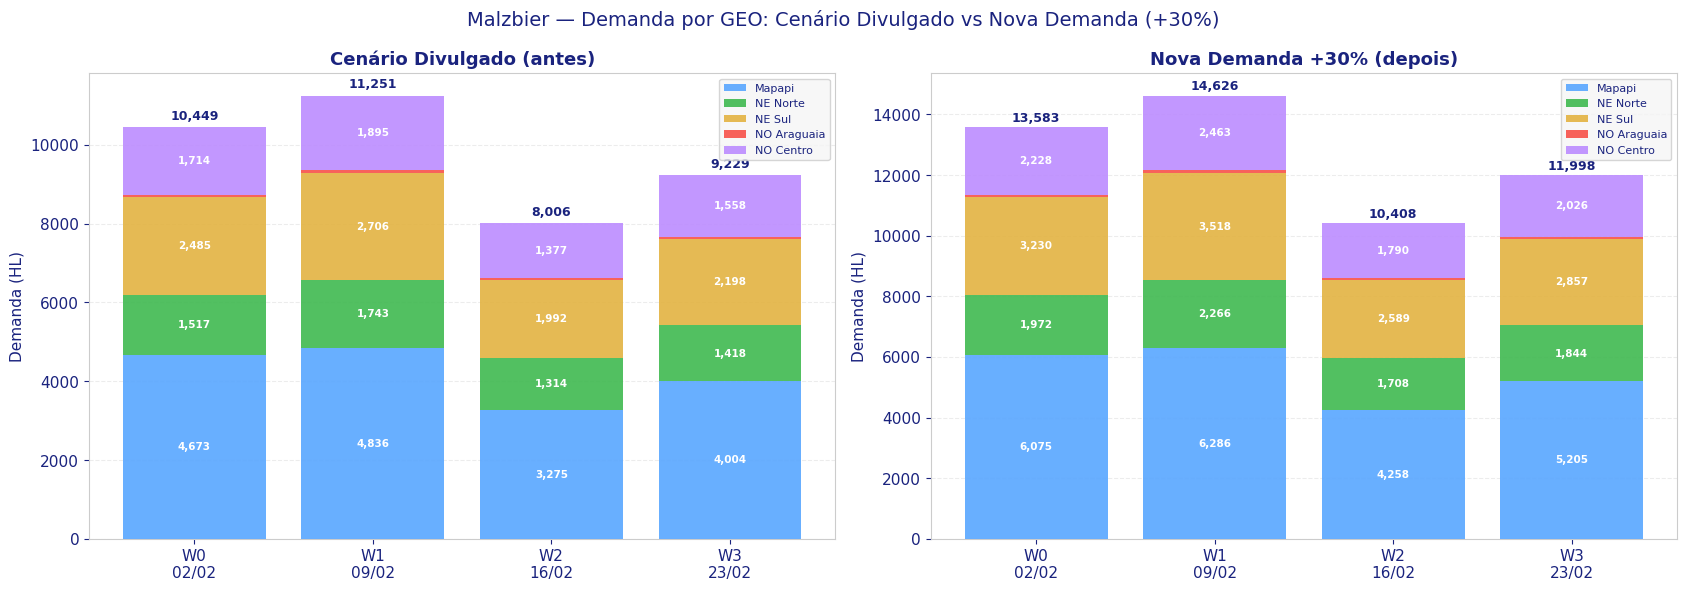

In [72]:

geo_cores = ['#58a6ff','#3fb950','#e3b341','#f85149','#bc8cff']
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Malzbier — Demanda por GEO: Cenário Divulgado vs Nova Demanda (+30%)', fontsize=14)

for ax_i, (label, dem_geo) in enumerate([('Cenário Divulgado (antes)', dem_malz_cd),
                                           ('Nova Demanda +30% (depois)', dem_malz_nd)]):
    ax  = axes[ax_i]
    xp  = np.arange(4)
    bot = np.zeros(4)
    for j, geo in enumerate(GEOS):
        vals = np.array(dem_geo[geo])
        ax.bar(xp, vals, bottom=bot, color=geo_cores[j], label=geo, alpha=0.9, zorder=3)
        for k in range(4):
            if vals[k] > 120:
                ax.text(xp[k], bot[k]+vals[k]/2, f'{vals[k]:,.0f}',
                        ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')
        bot += vals
    totais = [sum(dem_geo[g][i] for g in GEOS) for i in range(4)]
    for k, t in enumerate(totais):
        ax.text(xp[k], t+200, f'{t:,.0f}', ha='center', fontsize=9, color=TEXT_C, fontweight='bold')
    ax.set_xticks(xp); ax.set_xticklabels(SEMS)
    ax.set_title(label); ax.set_ylabel('Demanda (HL)')
    ax.legend(loc='upper right', fontsize=8); ax.grid(axis='y', zorder=0)

plt.tight_layout(); plt.savefig('g1_demanda_geo.png', dpi=150, bbox_inches='tight',
    facecolor='#ffffff'); plt.show()


## 2. Demanda Total Malzbier — Evolução Semanal e Delta

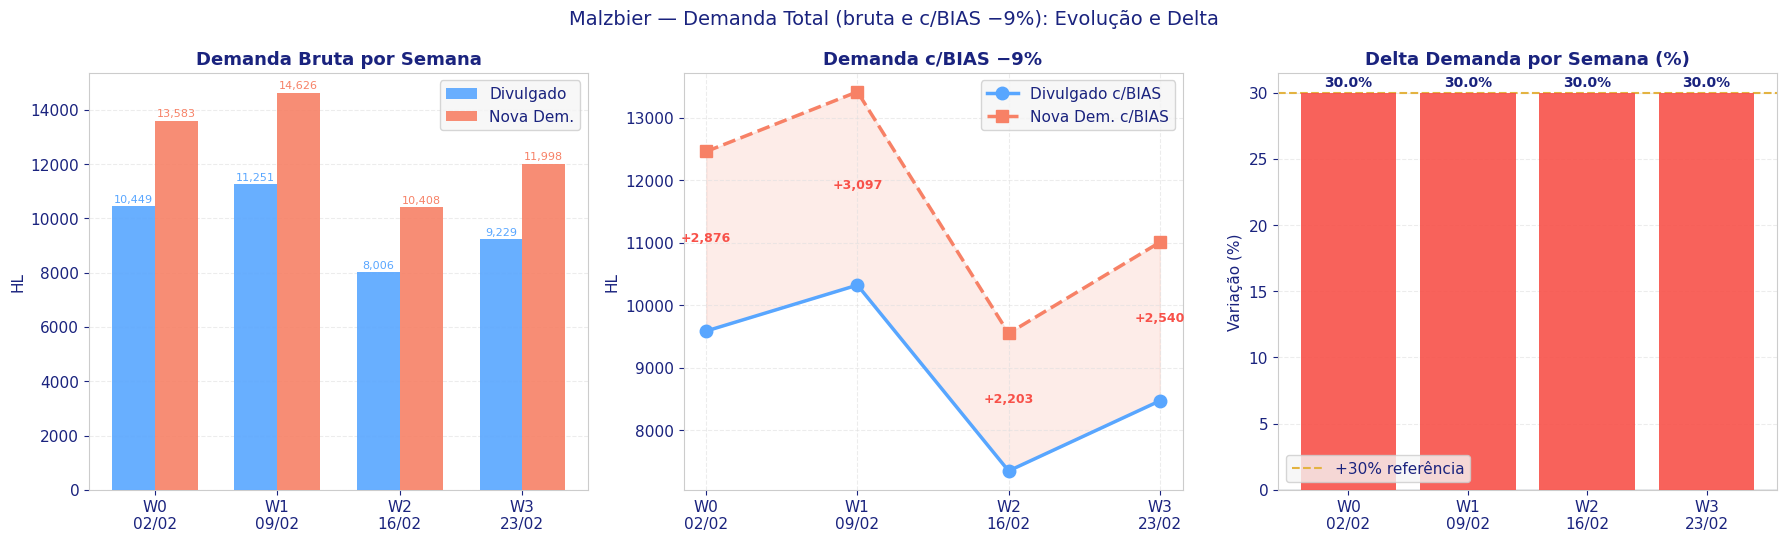

In [73]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Malzbier — Demanda Total (bruta e c/BIAS −9%): Evolução e Delta', fontsize=14)

xp = np.arange(4); w = 0.35

# Barras agrupadas — bruta
ax = axes[0]
b1 = ax.bar(xp-w/2, dem_tot_cd, w, color=ANTES,  alpha=0.9, label='Divulgado', zorder=3)
b2 = ax.bar(xp+w/2, dem_tot_nd, w, color=DEPOIS, alpha=0.9, label='Nova Dem.', zorder=3)
for b in b1: ax.text(b.get_x()+b.get_width()/2, b.get_height()+150, f'{b.get_height():,.0f}',
                     ha='center', fontsize=8, color=ANTES)
for b in b2: ax.text(b.get_x()+b.get_width()/2, b.get_height()+150, f'{b.get_height():,.0f}',
                     ha='center', fontsize=8, color=DEPOIS)
ax.set_xticks(xp); ax.set_xticklabels(SEMS); ax.set_ylabel('HL')
ax.set_title('Demanda Bruta por Semana'); ax.legend(); ax.grid(axis='y', zorder=0)

# Linha c/BIAS
ax2 = axes[1]
ax2.plot(xp, dem_bias_cd, 'o-',  color=ANTES,  lw=2.5, ms=9, label='Divulgado c/BIAS')
ax2.plot(xp, dem_bias_nd, 's--', color=DEPOIS, lw=2.5, ms=9, label='Nova Dem. c/BIAS')
ax2.fill_between(xp, dem_bias_cd, dem_bias_nd, alpha=0.15, color=DEPOIS)
for i,(a,d) in enumerate(zip(dem_bias_cd, dem_bias_nd)):
    delta = d-a
    c = VERMELHO if delta>0 else VERDE
    ax2.annotate(f'+{delta:,.0f}', xy=(i,(a+d)/2), ha='center', fontsize=9,
                 color=c, fontweight='bold')
ax2.set_xticks(xp); ax2.set_xticklabels(SEMS); ax2.set_ylabel('HL')
ax2.set_title('Demanda c/BIAS −9%'); ax2.legend(); ax2.grid(zorder=0)

# Delta % por semana
ax3 = axes[2]
delta_pct = [(d-a)/a*100 for a,d in zip(dem_bias_cd, dem_bias_nd)]
cores_delta = [VERMELHO if v>0 else VERDE for v in delta_pct]
bars = ax3.bar(xp, delta_pct, color=cores_delta, alpha=0.9, zorder=3)
ax3.axhline(0, color=CINZA, lw=1)
ax3.axhline(30, color=AMARELO, lw=1.5, ls='--', label='+30% referência')
for b, v in zip(bars, delta_pct):
    ax3.text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.1f}%',
             ha='center', fontsize=10, fontweight='bold', color=TEXT_C)
ax3.set_xticks(xp); ax3.set_xticklabels(SEMS); ax3.set_ylabel('Variação (%)')
ax3.set_title('Delta Demanda por Semana (%)'); ax3.legend(); ax3.grid(axis='y', zorder=0)

plt.tight_layout(); plt.savefig('g2_demanda_total.png', dpi=150, bbox_inches='tight',
    facecolor='#ffffff'); plt.show()


## 3. Estoque Inicial W0 por GEO — Malzbier

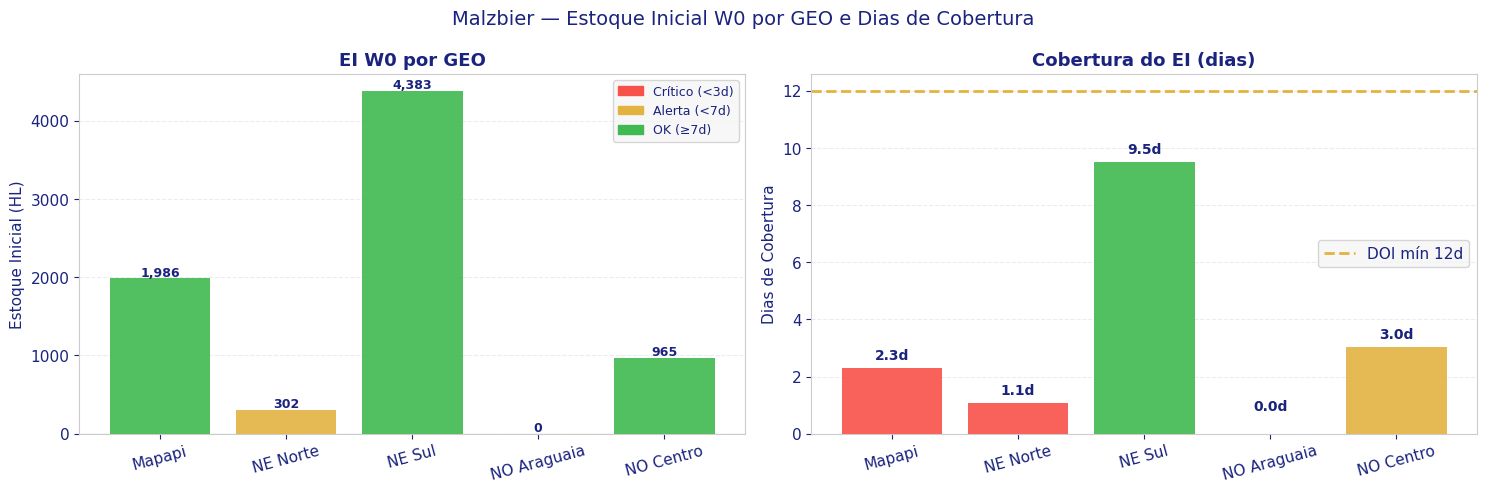

⚠️  NE Norte: EI=302 HL → 1.1d — risco de ruptura em W0!


In [74]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Malzbier — Estoque Inicial W0 por GEO e Dias de Cobertura', fontsize=14)

geos_l = list(ei_malz.keys())
ei_vals = [ei_malz[g] for g in geos_l]
dem_w0  = [dem_malz_nd[g][0] for g in geos_l]

# Barras EI
ax = axes[0]
cores_ei = [VERMELHO if ei_malz[g] < dem_malz_nd[g][0]/7 else
            (AMARELO  if ei_malz[g] < dem_malz_nd[g][0]*12/6/7 else VERDE)
            for g in geos_l]
bars = ax.bar(geos_l, ei_vals, color=cores_ei, alpha=0.9, zorder=3)
for b, v in zip(bars, ei_vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+30, f'{v:,.0f}',
            ha='center', fontsize=9, fontweight='bold', color=TEXT_C)
ax.set_ylabel('Estoque Inicial (HL)'); ax.set_title('EI W0 por GEO')
ax.tick_params(axis='x', rotation=15); ax.grid(axis='y', zorder=0)
ax.axhline(0, color=CINZA, lw=0.8)

# DOI do EI (cobertura em dias = EI / (dem_w0/7))
doi_ei = [ei_malz[g] / (dem_malz_nd[g][0]/7) if dem_malz_nd[g][0]>0 else 0 for g in geos_l]
ax2 = axes[1]
cores_doi = [VERMELHO if d < 3 else (AMARELO if d < 7 else VERDE) for d in doi_ei]
bars2 = ax2.bar(geos_l, doi_ei, color=cores_doi, alpha=0.9, zorder=3)
ax2.axhline(12, color=AMARELO, lw=2, ls='--', label='DOI mín 12d')
for b, v in zip(bars2, doi_ei):
    ax2.text(b.get_x()+b.get_width()/2, max(v+0.3, 0.8), f'{v:.1f}d',
             ha='center', fontsize=10, fontweight='bold', color=TEXT_C)
ax2.set_ylabel('Dias de Cobertura'); ax2.set_title('Cobertura do EI (dias)')
ax2.tick_params(axis='x', rotation=15); ax2.legend(); ax2.grid(axis='y', zorder=0)

p_crit = mpatches.Patch(color=VERMELHO, label='Crítico (<3d)')
p_med  = mpatches.Patch(color=AMARELO,  label='Alerta (<7d)')
p_ok   = mpatches.Patch(color=VERDE,    label='OK (≥7d)')
axes[0].legend(handles=[p_crit,p_med,p_ok], fontsize=9)

plt.tight_layout(); plt.savefig('g3_estoque_inicial.png', dpi=150, bbox_inches='tight',
    facecolor='#ffffff'); plt.show()
print(f"⚠️  NE Norte: EI={ei_malz['NE Norte']:.0f} HL → {doi_ei[1]:.1f}d — risco de ruptura em W0!")


## 4. Balanço Malzbier — Estoque Final Semana a Semana

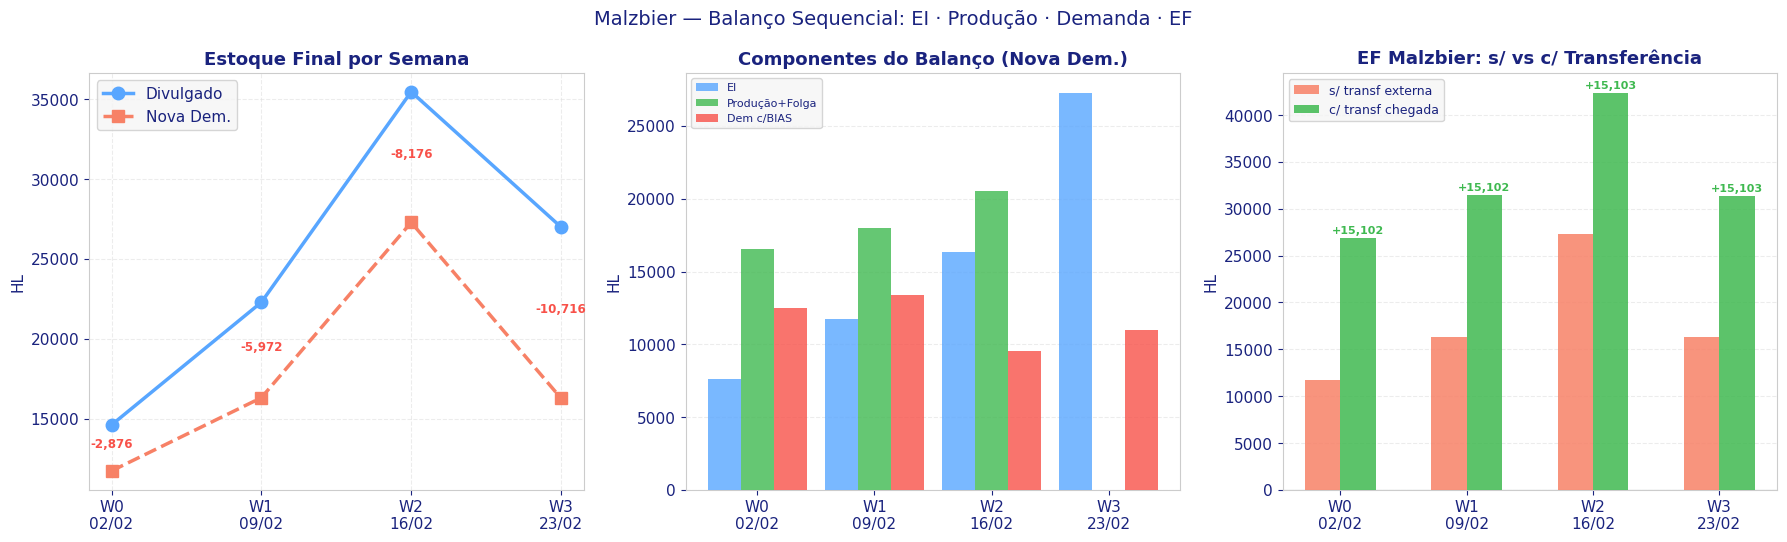

In [75]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Malzbier — Balanço Sequencial: EI · Produção · Demanda · EF', fontsize=14)

xp = np.arange(4)

ei_nd  = [r['EI'] for r in bal_nd];  ef_nd  = [r['EF'] for r in bal_nd]
ei_cd  = [r['EI'] for r in bal_cd];  ef_cd  = [r['EF'] for r in bal_cd]
prod_v = [r['prod'] for r in bal_nd]

# EF comparativo
ax = axes[0]
ax.plot(xp, ef_cd, 'o-',  color=ANTES,  lw=2.5, ms=9, label='Divulgado')
ax.plot(xp, ef_nd, 's--', color=DEPOIS, lw=2.5, ms=9, label='Nova Dem.')
for i,(a,d) in enumerate(zip(ef_cd, ef_nd)):
    c = VERMELHO if d<a else VERDE
    ax.annotate(f'{d-a:+,.0f}', xy=(i,(a+d)/2), ha='center', fontsize=8.5,
                color=c, fontweight='bold')
ax.set_xticks(xp); ax.set_xticklabels(SEMS); ax.set_ylabel('HL')
ax.set_title('Estoque Final por Semana'); ax.legend(); ax.grid(zorder=0)

# Waterfall W (ND)
ax2 = axes[1]
w = 0.28
ax2.bar(xp-w, ei_nd,  w, color='#58a6ff', alpha=0.8, label='EI', zorder=3)
ax2.bar(xp,   prod_v, w, color=VERDE,     alpha=0.8, label='Produção+Folga', zorder=3)
ax2.bar(xp+w, [r['dem'] for r in bal_nd], w, color=VERMELHO, alpha=0.8, label='Dem c/BIAS', zorder=3)
ax2.set_xticks(xp); ax2.set_xticklabels(SEMS); ax2.set_ylabel('HL')
ax2.set_title('Componentes do Balanço (Nova Dem.)'); ax2.legend(fontsize=8); ax2.grid(axis='y', zorder=0)

# EF pós-transferência vs sem
ef_com_transf = transf_malz['ef_f']
ax3 = axes[2]
ax3.bar(xp-w/2, ef_nd,          w, color=DEPOIS,  alpha=0.85, label='s/ transf externa', zorder=3)
ax3.bar(xp+w/2, ef_com_transf,  w, color=VERDE,   alpha=0.85, label='c/ transf chegada', zorder=3)
ax3.axhline(0, color=CINZA, lw=0.8)
for i,(a,b) in enumerate(zip(ef_nd, ef_com_transf)):
    if b!=a:
        ax3.annotate(f'+{b-a:,.0f}', xy=(i+w/2, b+500), ha='center',
                     fontsize=8, color=VERDE, fontweight='bold')
ax3.set_xticks(xp); ax3.set_xticklabels(SEMS); ax3.set_ylabel('HL')
ax3.set_title('EF Malzbier: s/ vs c/ Transferência'); ax3.legend(fontsize=9); ax3.grid(axis='y', zorder=0)

plt.tight_layout(); plt.savefig('g4_balanco_ef.png', dpi=150, bbox_inches='tight',
    facecolor='#ffffff'); plt.show()


## 5. DOI (Dias de Inventário) — Todos os SKUs

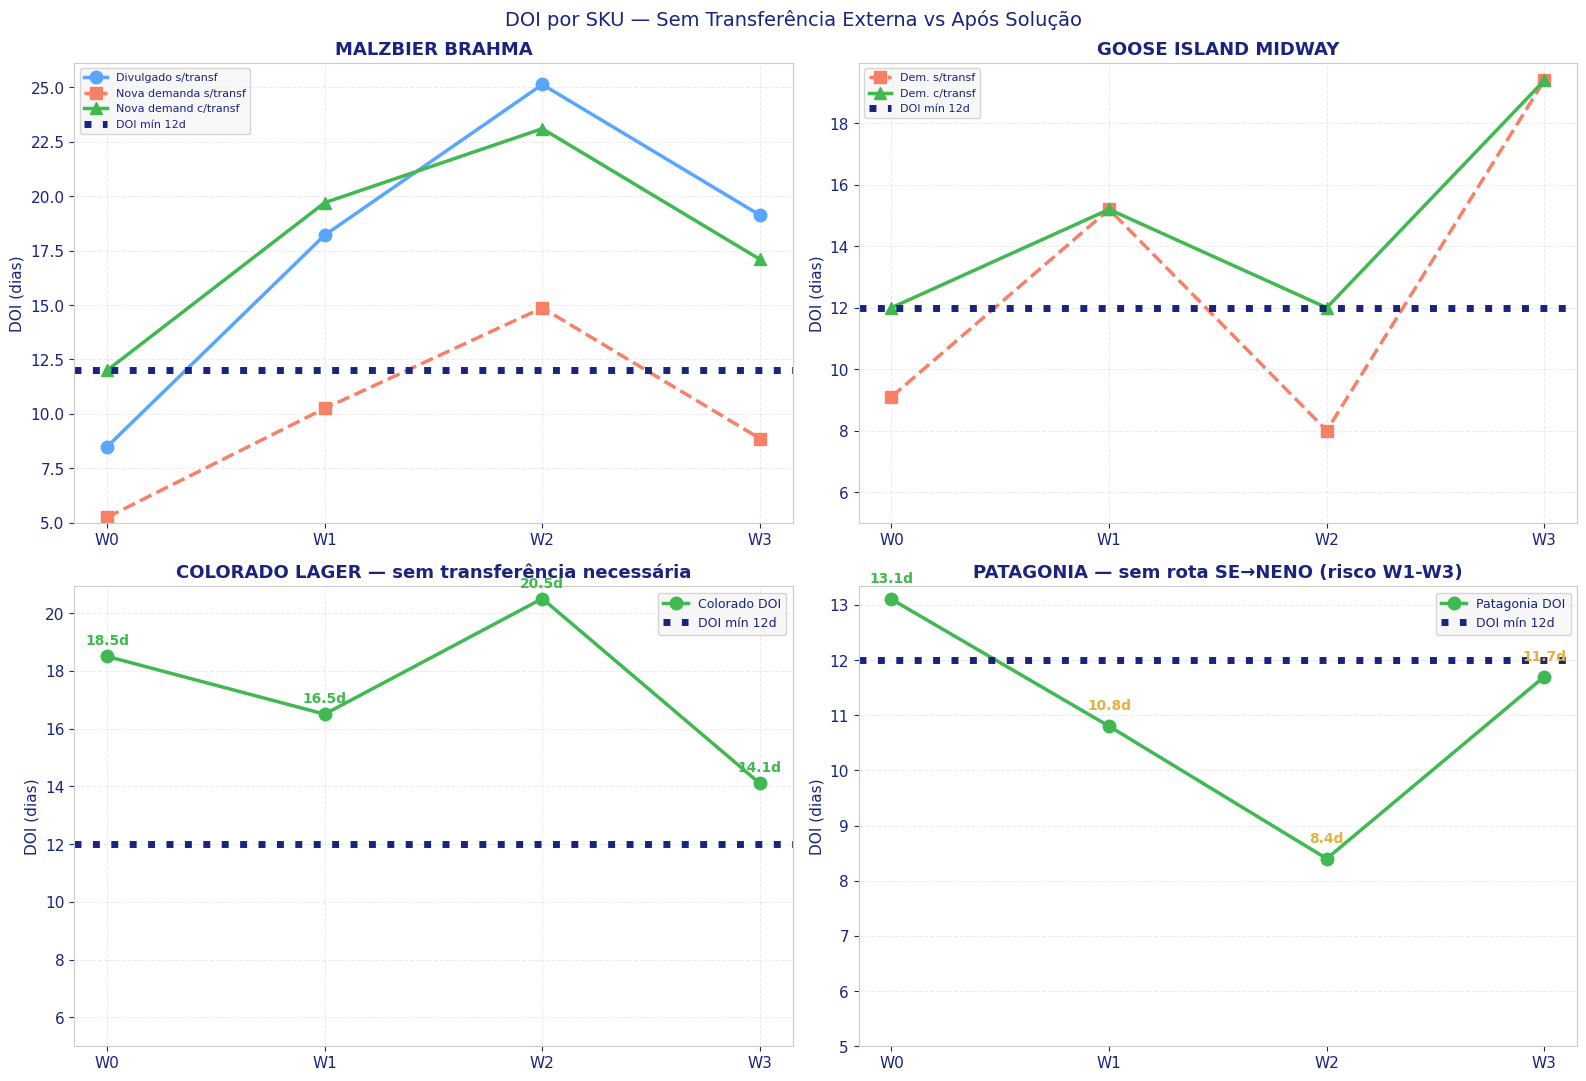

In [76]:

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('DOI por SKU — Sem Transferência Externa vs Após Solução', fontsize=14)
axes = axes.flatten()

# MALZBIER
ax = axes[0]
doi_nd_st = [r['DOI'] for r in bal_nd]   # sem transf
doi_cd_st = [r['DOI'] for r in bal_cd]
doi_nd_cf = transf_malz['doi_f']          # com transf

ax.plot(np.arange(4), doi_cd_st, 'o-',  color=ANTES,  lw=2.5, ms=9, label='Divulgado s/transf')
ax.plot(np.arange(4), doi_nd_st, 's--', color=DEPOIS, lw=2.5, ms=9, label='Nova demanda s/transf')
ax.plot(np.arange(4), doi_nd_cf, '^-',  color=VERDE,  lw=2.5, ms=9, label='Nova demand c/transf')
ax.axhline(12, color=TEXT_C, lw=5, ls=':', label='DOI mín 12d')
#for i, (s, d) in enumerate(zip(doi_nd_st, doi_nd_cf)):
    #if d > s:
        #ax.annotate('', xy=(i, d), xytext=(i, s),
                    #arrowprops=dict(arrowstyle='->', color=VERDE, lw=1.8))
ax.set_xticks(np.arange(4)); ax.set_xticklabels(SEMS_S)
ax.set_title('MALZBIER BRAHMA'); ax.set_ylabel('DOI (dias)')
ax.set_ylim(bottom=5); ax.legend(fontsize=8); ax.grid(zorder=0)

# GOOSE
ax2 = axes[1]
doi_g_st = transf_goose['doi_st']
doi_g_cf = transf_goose['doi_f']
ax2.plot(np.arange(4), doi_g_st, 's--', color=DEPOIS, lw=2.5, ms=9, label='Dem. s/transf')
ax2.plot(np.arange(4), doi_g_cf, '^-',  color=VERDE,  lw=2.5, ms=9, label='Dem. c/transf')
ax2.axhline(12, color=TEXT_C, lw=5, ls=':', label='DOI mín 12d')
#for i,(s,d) in enumerate(zip(doi_g_st, doi_g_cf)):
    #if d>s:
        #ax2.annotate('', xy=(i,d), xytext=(i,s),
                     #arrowprops=dict(arrowstyle='->', color=VERDE, lw=1.8))
ax2.set_xticks(np.arange(4)); ax2.set_xticklabels(SEMS_S)
ax2.set_title('GOOSE ISLAND MIDWAY'); ax2.set_ylabel('DOI (dias)')
ax2.set_ylim(bottom=5); ax2.legend(fontsize=8); ax2.grid(zorder=0)

# COLORADO
ax3 = axes[2]
ax3.plot(np.arange(4), colorado_doi, 'o-', color=VERDE, lw=2.5, ms=9, label='Colorado DOI')
ax3.axhline(12, color=TEXT_C, lw=5, ls=':', label='DOI mín 12d')
for i, d in enumerate(colorado_doi):
    ax3.text(i, d+0.4, f'{d:.1f}d', ha='center', fontsize=10, color=VERDE, fontweight='bold')
ax3.set_xticks(np.arange(4)); ax3.set_xticklabels(SEMS_S)
ax3.set_title('COLORADO LAGER — sem transferência necessária')
ax3.set_ylabel('DOI (dias)'); ax3.set_ylim(bottom=5); ax3.legend(fontsize=9); ax3.grid(zorder=0)

# PATAGONIA
ax4 = axes[3]
ax4.plot(np.arange(4), patagonia_doi, 'o-', color=VERDE, lw=2.5, ms=9, label='Patagonia DOI')
ax4.axhline(12, color=TEXT_C, lw=5, ls=':', label='DOI mín 12d')
for i, d in enumerate(patagonia_doi):
    ax4.text(i, d+0.3, f'{d:.1f}d', ha='center', fontsize=10,
             color=VERDE if d>=12 else AMARELO, fontweight='bold')
ax4.set_xticks(np.arange(4)); ax4.set_xticklabels(SEMS_S)
ax4.set_title('PATAGONIA — sem rota SE→NENO (risco W1-W3)')
ax4.set_ylabel('DOI (dias)'); ax4.set_ylim(bottom=5); ax4.legend(fontsize=9); ax4.grid(axis='y', zorder=0)

plt.tight_layout(); plt.savefig('g5_doi_todos_skus.png', dpi=150, bbox_inches='tight',
    facecolor='#ffffff'); plt.show()

## 6. Heatmap de DOI — Visão Consolidada de Risco

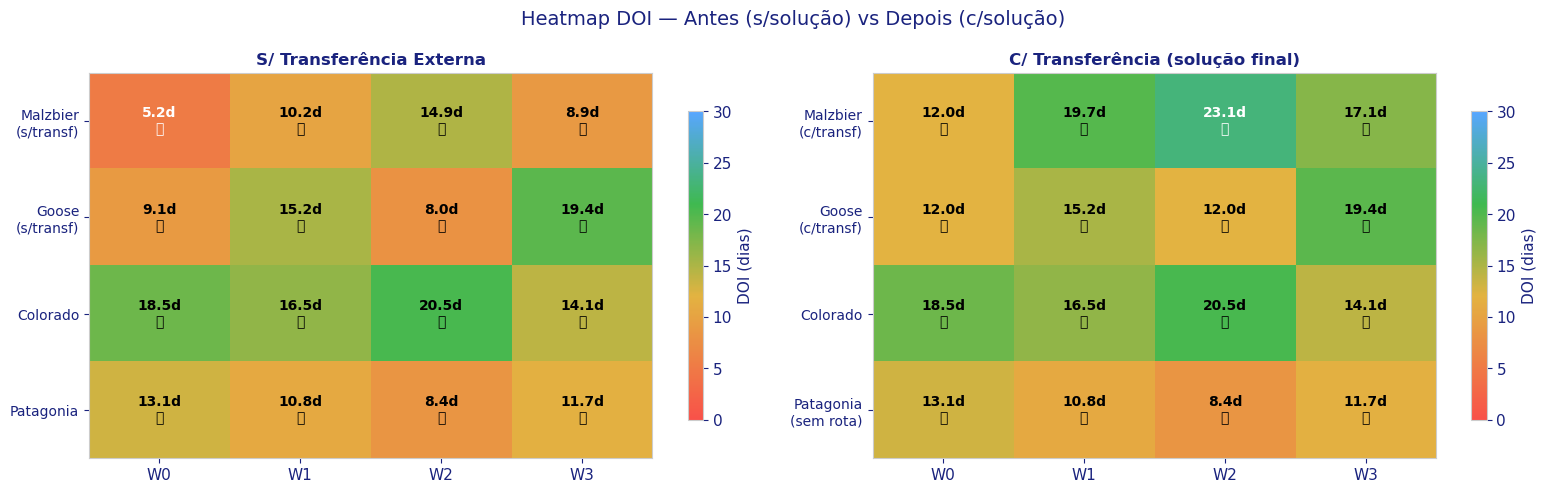

In [77]:

from matplotlib.colors import LinearSegmentedColormap

# DOI final (pós-solução) de cada SKU por semana
doi_matrix = np.array([
    transf_malz['doi_f'],    # Malzbier
    transf_goose['doi_f'],   # Goose
    colorado_doi,            # Colorado
    patagonia_doi,           # Patagonia
])
sku_labels = ['Malzbier\n(c/transf)', 'Goose\n(c/transf)', 'Colorado', 'Patagonia\n(sem rota)']

# DOI sem solução
doi_matrix_st = np.array([
    [r['DOI'] for r in bal_nd],
    transf_goose['doi_st'],
    colorado_doi,
    patagonia_doi,
])
sku_labels_st = ['Malzbier\n(s/transf)', 'Goose\n(s/transf)', 'Colorado', 'Patagonia']

cmap = LinearSegmentedColormap.from_list('risk',
    [(0,'#f85149'),(0.4,'#e3b341'),(0.7,'#3fb950'),(1.0,'#58a6ff')])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Heatmap DOI — Antes (s/solução) vs Depois (c/solução)', fontsize=14)

for ax, mat, labels, title in [
        (axes[0], doi_matrix_st, sku_labels_st, 'S/ Transferência Externa'),
        (axes[1], doi_matrix,    sku_labels,    'C/ Transferência (solução final)')]:
    im = ax.imshow(mat, cmap=cmap, aspect='auto', vmin=0, vmax=30)
    ax.set_xticks(range(4)); ax.set_xticklabels(SEMS_S)
    ax.set_yticks(range(4)); ax.set_yticklabels(labels, fontsize=10)
    for i in range(4):
        for j in range(4):
            v = mat[i,j]
            txt_c = 'white' if v < 8 or v > 22 else 'black'
            status = '✅' if v>=12 else '🚨'
            ax.text(j, i, f'{v:.1f}d\n{status}', ha='center', va='center',
                    fontsize=10, color=txt_c, fontweight='bold')
    ax.set_title(title, fontsize=12)
    plt.colorbar(im, ax=ax, label='DOI (dias)', shrink=0.8)

plt.tight_layout(); plt.savefig('g6_doi_heatmap.png', dpi=150, bbox_inches='tight',
    facecolor='#ffffff'); plt.show()


## 7. Transferências — Volume e Distribuição por CDR

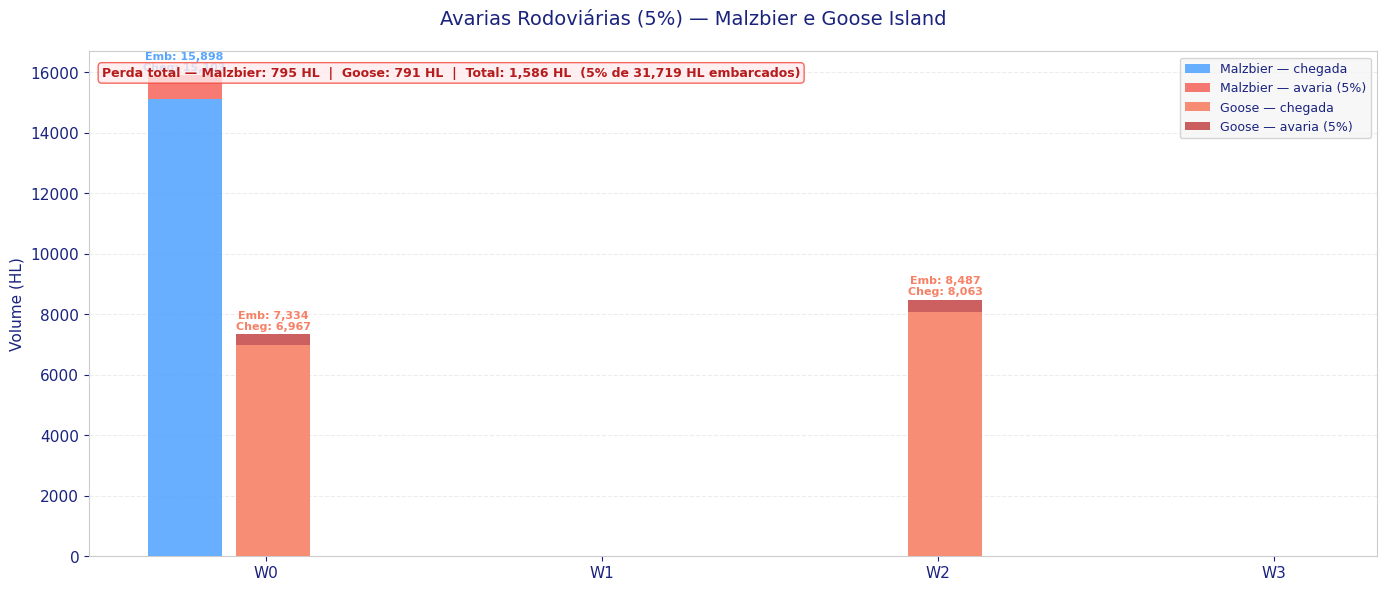

In [78]:
AVARIA = 0.05
xp = np.arange(4)
w  = 0.22

# Volume embarcado por SKU/semana
emb_malz  = [transf_malz['emb_ba'][i]  + transf_malz['emb_pb'][i]  for i in range(4)]
emb_goose = [transf_goose['emb_ba'][i] + transf_goose['emb_pb'][i] for i in range(4)]

# Chegada (após avaria) e perda
cheg_malz  = [v * (1 - AVARIA) for v in emb_malz]
cheg_goose = [v * (1 - AVARIA) for v in emb_goose]
av_malz    = [v * AVARIA       for v in emb_malz]
av_goose   = [v * AVARIA       for v in emb_goose]

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Avarias Rodoviárias (5%) — Malzbier e Goose Island', fontsize=14)

# Barras empilhadas: chegada (base) + avaria (topo)
x_malz  = xp - w * 1.1
x_goose = xp + w * 0.1

ax.bar(x_malz,  cheg_malz,  w, color=ANTES,      alpha=0.90, label='Malzbier — chegada',    zorder=3)
ax.bar(x_malz,  av_malz,    w, color='#f44336',  alpha=0.70, label='Malzbier — avaria (5%)',
       bottom=cheg_malz, zorder=3)
ax.bar(x_goose, cheg_goose, w, color=DEPOIS,     alpha=0.90, label='Goose — chegada',       zorder=3)
ax.bar(x_goose, av_goose,   w, color='#b71c1c',  alpha=0.70, label='Goose — avaria (5%)',
       bottom=cheg_goose, zorder=3)

# Rótulos: embarcado / chegada por barra
for i in range(4):
    if emb_malz[i] > 0:
        ax.text(x_malz[i], emb_malz[i] + 150,
                f'Emb: {emb_malz[i]:,.0f}\nCheg: {cheg_malz[i]:,.0f}',
                ha='center', fontsize=8, color=ANTES, fontweight='bold')
    if emb_goose[i] > 0:
        ax.text(x_goose[i], emb_goose[i] + 150,
                f'Emb: {emb_goose[i]:,.0f}\nCheg: {cheg_goose[i]:,.0f}',
                ha='center', fontsize=8, color=DEPOIS, fontweight='bold')

# Totais de avaria no rodapé
tot_av_m = sum(av_malz)
tot_av_g = sum(av_goose)
ax.text(0.01, 0.97,
        f'Perda total — Malzbier: {tot_av_m:,.0f} HL  |  Goose: {tot_av_g:,.0f} HL  |  '
        f'Total: {tot_av_m + tot_av_g:,.0f} HL  (5% de {sum(emb_malz)+sum(emb_goose):,.0f} HL embarcados)',
        transform=ax.transAxes, fontsize=9, color='#b71c1c', fontweight='bold',
        va='top', bbox=dict(boxstyle='round,pad=0.3', fc='#ffebee', ec='#f44336', alpha=0.8))

ax.set_xticks(xp)
ax.set_xticklabels(SEMS_S)
ax.set_ylabel('Volume (HL)')
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', zorder=0)

plt.tight_layout()
plt.savefig('g7b_avarias.png', dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()

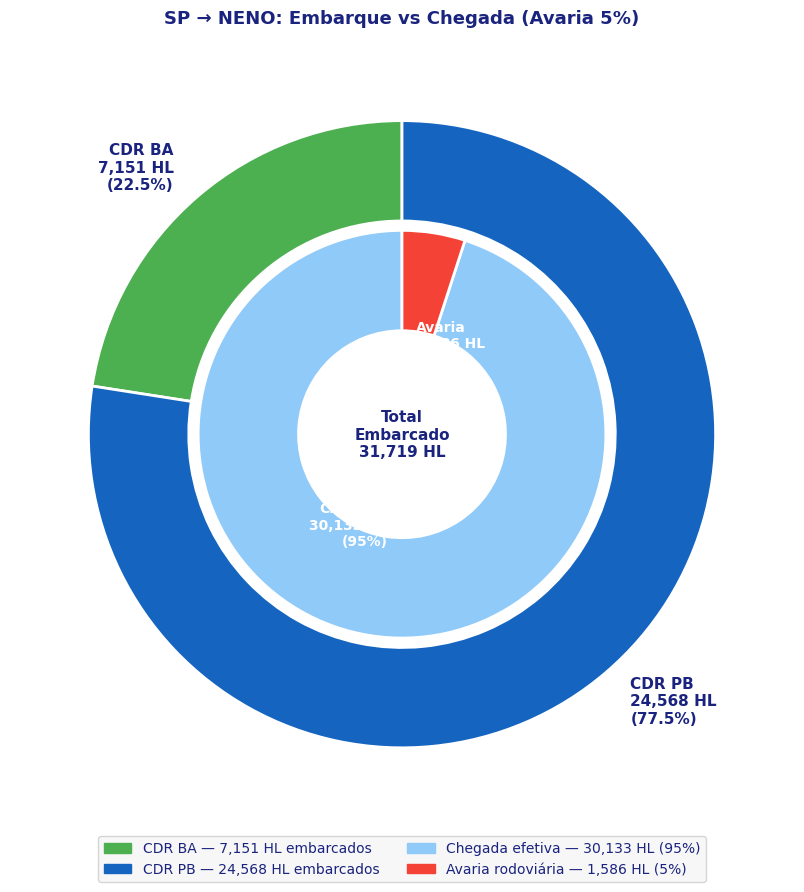

In [79]:
AVARIA = 0.05

# Totais consolidados (Malzbier + Goose, todas as semanas)
emb_ba_tot = sum(transf_malz['emb_ba']) + sum(transf_goose['emb_ba'])
emb_pb_tot = sum(transf_malz['emb_pb']) + sum(transf_goose['emb_pb'])
emb_total  = emb_ba_tot + emb_pb_tot
cheg_total = emb_total * (1 - AVARIA)
av_total   = emb_total * AVARIA

fig, ax = plt.subplots(figsize=(9, 9))
fig.suptitle('SP → NENO: Embarque vs Chegada (Avaria 5%)', fontsize=13, fontweight='bold')

# ── Anel externo: composição do embarque (BA + PB)
outer_sizes  = [emb_ba_tot, emb_pb_tot]
outer_colors = ['#4caf50', '#1565c0']
outer_labels = [
    f'CDR BA\n{emb_ba_tot:,.0f} HL\n({emb_ba_tot/emb_total*100:.1f}%)',
    f'CDR PB\n{emb_pb_tot:,.0f} HL\n({emb_pb_tot/emb_total*100:.1f}%)',
]
wedges_out, _ = ax.pie(
    outer_sizes,
    labels=outer_labels,
    colors=outer_colors,
    radius=1.0,
    startangle=90,
    wedgeprops=dict(width=0.32, edgecolor='white', linewidth=2),
    labeldistance=1.12,
    textprops={'fontsize': 11, 'color': '#1a237e', 'fontweight': 'bold'},
)

# ── Anel interno: chegada vs avaria
inner_sizes  = [cheg_total, av_total]
inner_colors = ['#90caf9', '#f44336']
inner_labels = [
    f'Chegada\n{cheg_total:,.0f} HL\n(95%)',
    f'Avaria\n{av_total:,.0f} HL\n(5%)',
]
wedges_in, _ = ax.pie(
    inner_sizes,
    labels=inner_labels,
    colors=inner_colors,
    radius=0.65,
    startangle=90,
    wedgeprops=dict(width=0.32, edgecolor='white', linewidth=2),
    labeldistance=0.45,
    textprops={'fontsize': 10, 'color': 'white', 'fontweight': 'bold'},
)

# ── Centro: total embarcado
ax.text(0, 0, f'Total\nEmbarcado\n{emb_total:,.0f} HL',
        ha='center', va='center', fontsize=11,
        color='#1a237e', fontweight='bold')

# ── Legenda explicativa
import matplotlib.patches as mpatches
leg_handles = [
    mpatches.Patch(color='#4caf50', label=f'CDR BA — {emb_ba_tot:,.0f} HL embarcados'),
    mpatches.Patch(color='#1565c0', label=f'CDR PB — {emb_pb_tot:,.0f} HL embarcados'),
    mpatches.Patch(color='#90caf9', label=f'Chegada efetiva — {cheg_total:,.0f} HL (95%)'),
    mpatches.Patch(color='#f44336', label=f'Avaria rodoviária — {av_total:,.0f} HL (5%)'),
]
ax.legend(handles=leg_handles, loc='lower center', bbox_to_anchor=(0.5, -0.08),
          fontsize=10, frameon=True, ncol=2)

plt.tight_layout()
plt.savefig('g7b_pizza_avarias.png', dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()

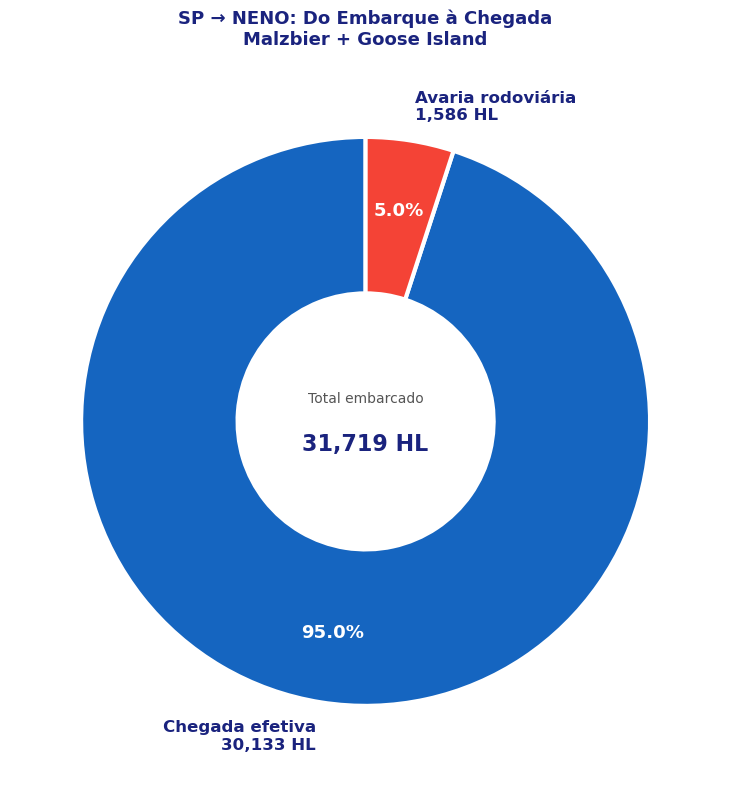

In [80]:
AVARIA = 0.05

# Totais consolidados (Malzbier + Goose, todas as semanas)
emb_ba_tot = sum(transf_malz['emb_ba']) + sum(transf_goose['emb_ba'])
emb_pb_tot = sum(transf_malz['emb_pb']) + sum(transf_goose['emb_pb'])
emb_total  = emb_ba_tot + emb_pb_tot
cheg_total = emb_total * (1 - AVARIA)
av_total   = emb_total * AVARIA

fig, ax = plt.subplots(figsize=(8, 8))
fig.suptitle('SP → NENO: Do Embarque à Chegada\nMalzbier + Goose Island', 
             fontsize=13, fontweight='bold')

sizes  = [cheg_total, av_total]
colors = ['#1565c0', '#f44336']
labels = [
    f'Chegada efetiva\n{cheg_total:,.0f} HL',
    f'Avaria rodoviária\n{av_total:,.0f} HL',
]

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=3),
    labeldistance=1.12,
    pctdistance=0.75,
    textprops={'fontsize': 12, 'color': '#1a237e', 'fontweight': 'bold'},
)

for at in autotexts:
    at.set_color('white')
    at.set_fontsize(13)
    at.set_fontweight('bold')

# Centro: total embarcado
ax.text(0, 0.08, 'Total embarcado', ha='center', va='center',
        fontsize=10, color='#555555')
ax.text(0, -0.08, f'{emb_total:,.0f} HL',
        ha='center', va='center', fontsize=16,
        color='#1a237e', fontweight='bold')

plt.tight_layout()
plt.savefig('g7b_pizza_avarias.png', dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()

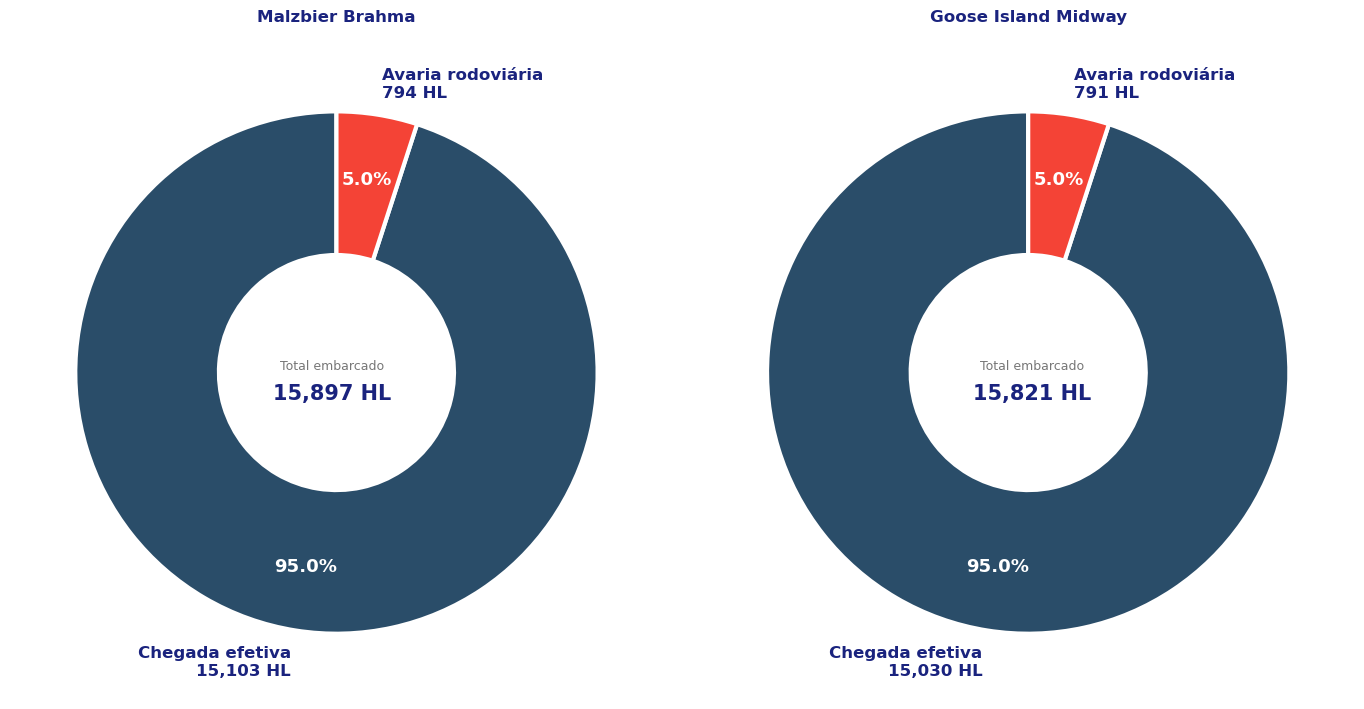

In [81]:
AVARIA = 0.05

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
#fig.suptitle('Transferência Rodoviária SP → NENO: Embarque vs Chegada',
             #fontsize=13, fontweight='bold', color='#1a237e')

skus = [
    {'ax': axes[0], 'titulo': 'Malzbier Brahma',     'emb_total': 15897, 'cheg': 15103},
    {'ax': axes[1], 'titulo': 'Goose Island Midway', 'emb_total': 15821, 'cheg': 15030},
]

for s in skus:
    ax   = s['ax']
    emb  = s['emb_total']
    cheg = s['cheg']
    av   = emb - cheg

    wedges, texts, autotexts = ax.pie(
        [cheg, av],
        labels=[f'Chegada efetiva\n{cheg:,.0f} HL', f'Avaria rodoviária\n{av:,.0f} HL'],
        colors=['#2a4d69', '#f44336'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(width=0.55, edgecolor='white', linewidth=3),
        labeldistance=1.12,
        pctdistance=0.75,
        textprops={'fontsize': 12, 'color': '#1a237e', 'fontweight': 'bold'},
    )
    for at in autotexts:
        at.set_color('white'); at.set_fontsize(13); at.set_fontweight('bold')

    # Centro: converter coordenadas do eixo para figura
    #x0, y0 = ax.transAxes.transform((0.5, 0.5))
    #xf, yf = fig.transFigure.inverted().transform((x0, y0))
   #fig.text(xf - 0.05, yf + 0.03, 'Total embarcado', ha='center', va='center',
             #fontsize=9, color='#555555', transform=fig.transFigure)
    #fig.text(xf - 0.05, yf - 0.03, f'{emb:,.0f} HL', ha='center', va='center',
            # fontsize=15, color='#1a237e', fontweight='bold', transform=fig.transFigure)

    ax.set_title(s['titulo'], fontsize=12, fontweight='bold', color='#1a237e', pad=18)

fig.text(0.25, 0.50, 'Total embarcado',
         ha='center', va='center', fontsize=9,
         color='#777777', transform=fig.transFigure)
fig.text(0.25, 0.46, '15,897 HL',
         ha='center', va='center', fontsize=15,
         color='#1a237e', fontweight='bold', transform=fig.transFigure)

# ── Centro Goose (direita)
fig.text(0.75, 0.50, 'Total embarcado',
         ha='center', va='center', fontsize=9,
         color='#777777', transform=fig.transFigure)
fig.text(0.75, 0.46, '15,821 HL',
         ha='center', va='center', fontsize=15,
         color='#1a237e', fontweight='bold', transform=fig.transFigure)

plt.tight_layout()
plt.savefig('g7b_pizza_avarias.png', dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()

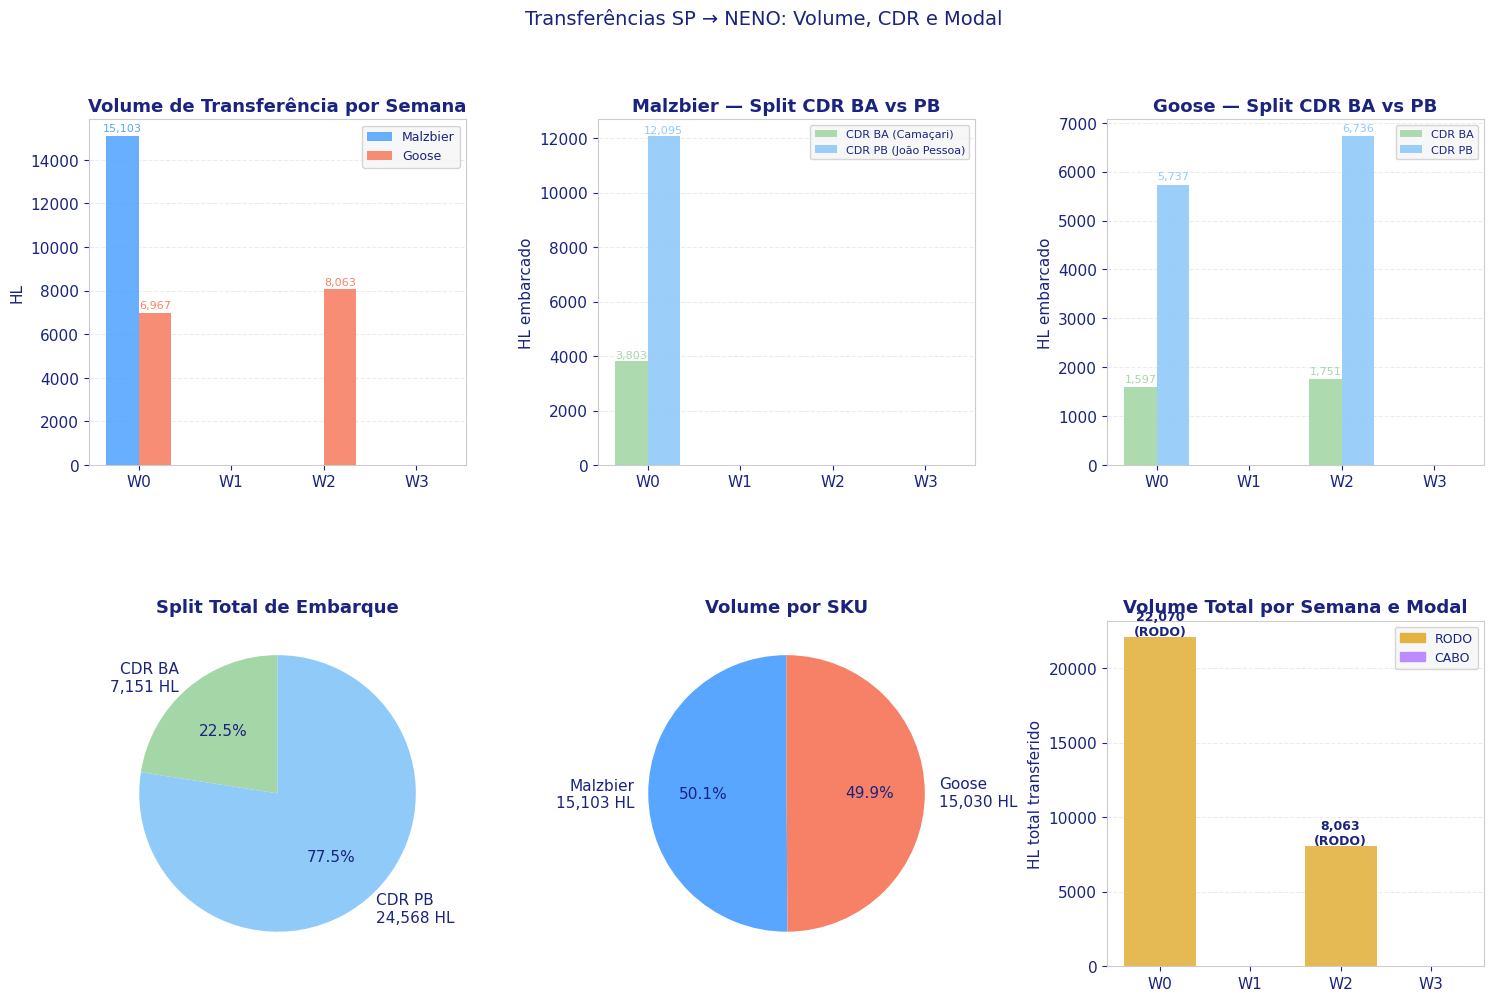

In [82]:

fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Transferências SP → NENO: Volume, CDR e Modal', fontsize=14)

xp = np.arange(4); w = 0.35

# ── Volume por semana (Malzbier e Goose)
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(xp-w/2, transf_malz['transf'], w, color=ANTES,  alpha=0.9, label='Malzbier', zorder=3)
ax1.bar(xp+w/2, transf_goose['transf'],w, color=DEPOIS, alpha=0.9, label='Goose',    zorder=3)
for i,(m,g) in enumerate(zip(transf_malz['transf'], transf_goose['transf'])):
    if m>0: ax1.text(i-w/2, m+200, f'{m:,.0f}', ha='center', fontsize=8, color=ANTES)
    if g>0: ax1.text(i+w/2, g+200, f'{g:,.0f}', ha='center', fontsize=8, color=DEPOIS)
ax1.set_xticks(xp); ax1.set_xticklabels(SEMS_S); ax1.set_ylabel('HL')
ax1.set_title('Volume de Transferência por Semana'); ax1.legend(fontsize=9); ax1.grid(axis='y', zorder=0)

# ── Split BA vs PB — Malzbier
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(xp-w/2, transf_malz['emb_ba'], w, color='#a5d6a7', alpha=0.9, label='CDR BA (Camaçari)', zorder=3)
ax2.bar(xp+w/2, transf_malz['emb_pb'], w, color='#90caf9', alpha=0.9, label='CDR PB (João Pessoa)', zorder=3)
for i,(a,b) in enumerate(zip(transf_malz['emb_ba'], transf_malz['emb_pb'])):
    if a>0: ax2.text(i-w/2, a+100, f'{a:,.0f}', ha='center', fontsize=8, color='#a5d6a7')
    if b>0: ax2.text(i+w/2, b+100, f'{b:,.0f}', ha='center', fontsize=8, color='#90caf9')
ax2.set_xticks(xp); ax2.set_xticklabels(SEMS_S); ax2.set_ylabel('HL embarcado')
ax2.set_title('Malzbier — Split CDR BA vs PB'); ax2.legend(fontsize=8); ax2.grid(axis='y', zorder=0)

# ── Split BA vs PB — Goose
ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(xp-w/2, transf_goose['emb_ba'], w, color='#a5d6a7', alpha=0.9, label='CDR BA', zorder=3)
ax3.bar(xp+w/2, transf_goose['emb_pb'], w, color='#90caf9', alpha=0.9, label='CDR PB', zorder=3)
for i,(a,b) in enumerate(zip(transf_goose['emb_ba'], transf_goose['emb_pb'])):
    if a>0: ax3.text(i-w/2, a+100, f'{a:,.0f}', ha='center', fontsize=8, color='#a5d6a7')
    if b>0: ax3.text(i+w/2, b+100, f'{b:,.0f}', ha='center', fontsize=8, color='#90caf9')
ax3.set_xticks(xp); ax3.set_xticklabels(SEMS_S); ax3.set_ylabel('HL embarcado')
ax3.set_title('Goose — Split CDR BA vs PB'); ax3.legend(fontsize=8); ax3.grid(axis='y', zorder=0)

# ── Pie: total BA vs PB
ax4 = fig.add_subplot(gs[1, 0])
ba_tot = sum(transf_malz['emb_ba'])+sum(transf_goose['emb_ba'])
pb_tot = sum(transf_malz['emb_pb'])+sum(transf_goose['emb_pb'])
ax4.pie([ba_tot, pb_tot], labels=[f'CDR BA\n{ba_tot:,.0f} HL', f'CDR PB\n{pb_tot:,.0f} HL'],
        colors=['#a5d6a7','#90caf9'], autopct='%1.1f%%', startangle=90,
        textprops={'color':TEXT_C,'fontsize':11})
ax4.set_title('Split Total de Embarque')

# ── Pie: Malzbier vs Goose
ax5 = fig.add_subplot(gs[1, 1])
tot_m = sum(transf_malz['transf']); tot_g = sum(transf_goose['transf'])
ax5.pie([tot_m, tot_g], labels=[f'Malzbier\n{tot_m:,.0f} HL', f'Goose\n{tot_g:,.0f} HL'],
        colors=[ANTES, DEPOIS], autopct='%1.1f%%', startangle=90,
        textprops={'color':TEXT_C,'fontsize':11})
ax5.set_title('Volume por SKU')

# ── Modal por semana (stacked: RODO vs CABO)
ax6 = fig.add_subplot(gs[1, 2])
rodo_v = [tm+tg for tm,tg in zip(transf_malz['transf'],transf_goose['transf'])]
# W3 seria cabo mas transf=0; indicar apenas modal usado
modais = ['RODO','RODO','RODO','CABO']
cores_mod = [AMARELO if m=='RODO' else ROXO for m in modais]
bars6 = ax6.bar(xp, rodo_v, color=cores_mod, alpha=0.9, zorder=3)
for b, v, m in zip(bars6, rodo_v, modais):
    if v>0:
        ax6.text(b.get_x()+b.get_width()/2, v+100, f'{v:,.0f}\n({m})',
                 ha='center', fontsize=9, fontweight='bold', color=TEXT_C)
ax6.set_xticks(xp); ax6.set_xticklabels(SEMS_S); ax6.set_ylabel('HL total transferido')
ax6.set_title('Volume Total por Semana e Modal')
p1 = mpatches.Patch(color=AMARELO, label='RODO')
p2 = mpatches.Patch(color=ROXO,    label='CABO')
ax6.legend(handles=[p1,p2], fontsize=9); ax6.grid(axis='y', zorder=0)

plt.savefig('g7_transferencias.png', dpi=150, bbox_inches='tight', facecolor='#ffffff'); plt.show()


## 8. Custos de Transferência e MACO Líquido

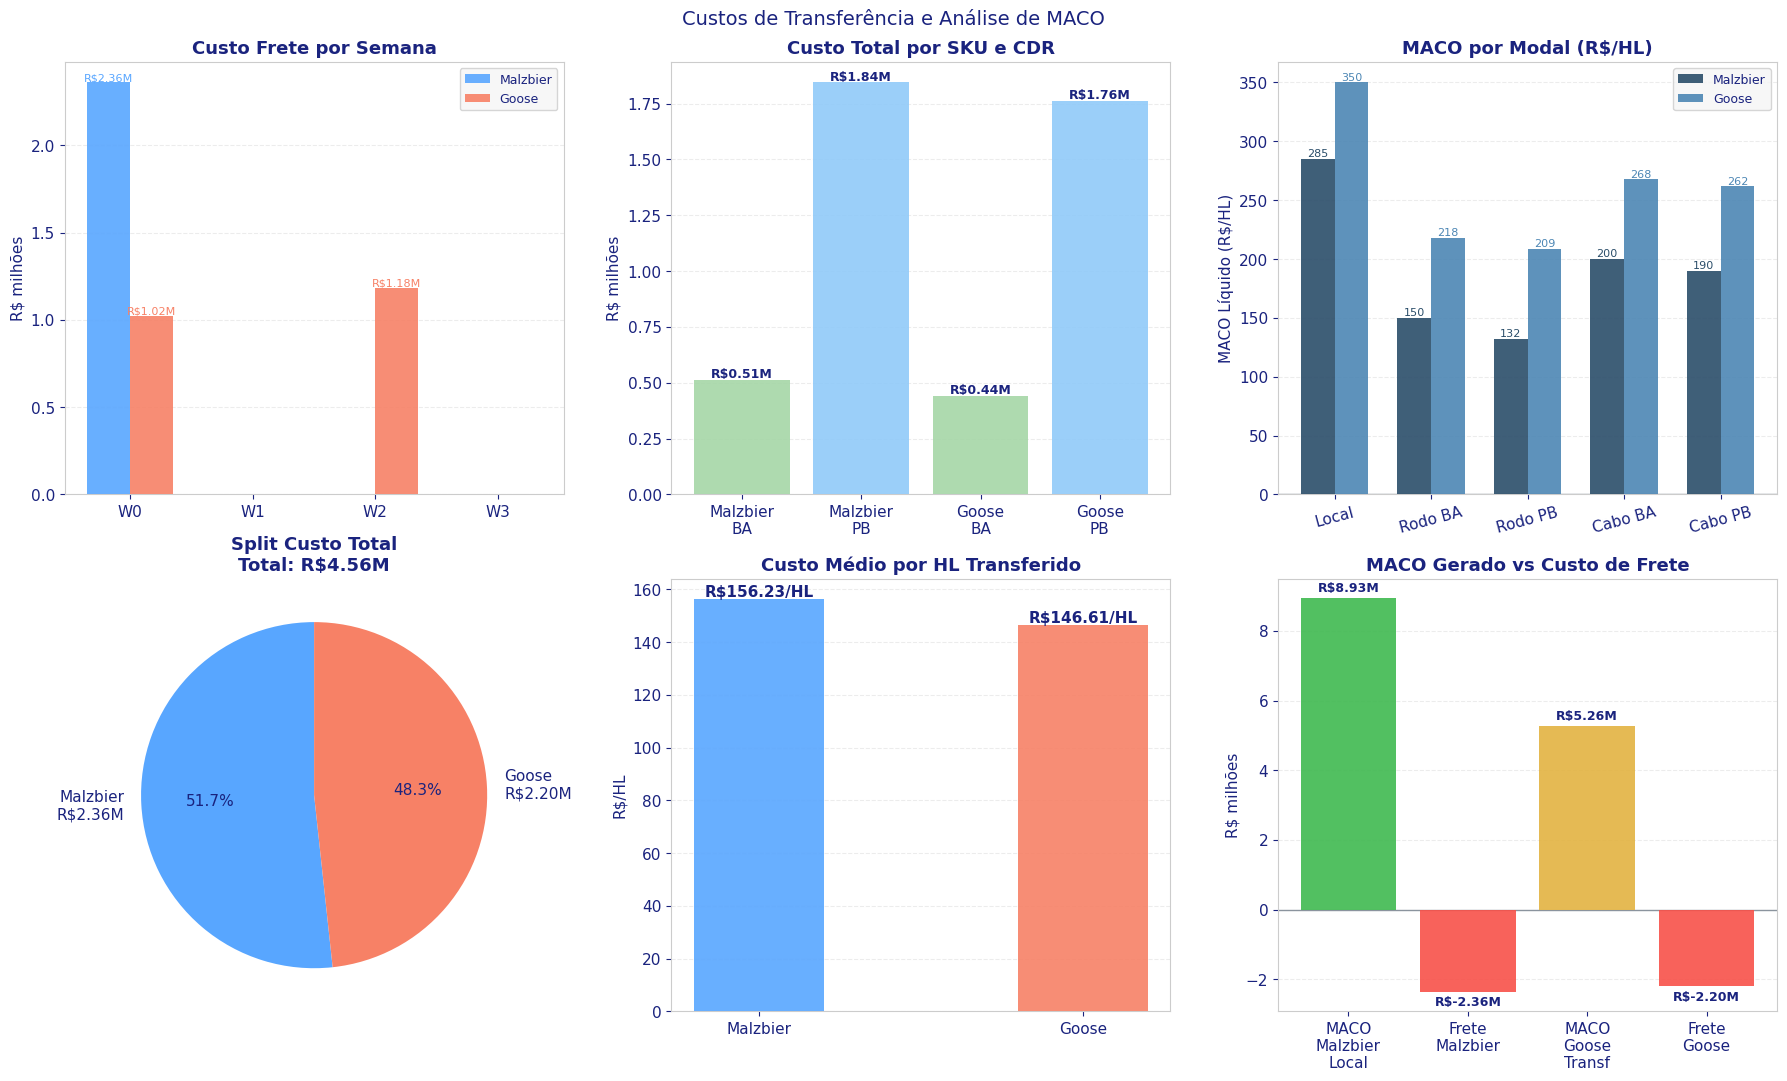

In [83]:

# Custo por semana e CDR
custo_m_ba = [3803*135.33, 0, 0, 0]
custo_m_pb = [12095*152.53, 0, 0, 0]
custo_g_ba = [1597*131.83, 0, 1751*131.83, 0]
custo_g_pb = [5737*141.28, 0, 6736*141.28, 0]

custo_sem_malz = [a+b for a,b in zip(custo_m_ba, custo_m_pb)]
custo_sem_goose= [a+b for a,b in zip(custo_g_ba, custo_g_pb)]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Custos de Transferência e Análise de MACO', fontsize=14)
axes = axes.flatten()

xp = np.arange(4); w = 0.35

# Custo por semana
ax = axes[0]
ax.bar(xp-w/2, [c/1e6 for c in custo_sem_malz], w, color=ANTES,  alpha=0.9, label='Malzbier', zorder=3)
ax.bar(xp+w/2, [c/1e6 for c in custo_sem_goose],w, color=DEPOIS, alpha=0.9, label='Goose',    zorder=3)
for i,(m,g) in enumerate(zip(custo_sem_malz, custo_sem_goose)):
    if m>0: ax.text(i-w/2, m/1e6+0.01, f'R${m/1e6:.2f}M', ha='center', fontsize=8, color=ANTES)
    if g>0: ax.text(i+w/2, g/1e6+0.01, f'R${g/1e6:.2f}M', ha='center', fontsize=8, color=DEPOIS)
ax.set_xticks(xp); ax.set_xticklabels(SEMS_S); ax.set_ylabel('R$ milhões')
ax.set_title('Custo Frete por Semana'); ax.legend(fontsize=9); ax.grid(axis='y', zorder=0)

# Custo total por SKU (barras com detalhe BA/PB)
ax2 = axes[1]
tot_malz_ba = sum(custo_m_ba); tot_malz_pb = sum(custo_m_pb)
tot_goose_ba= sum(custo_g_ba); tot_goose_pb= sum(custo_g_pb)
skus_c = ['Malzbier\nBA', 'Malzbier\nPB', 'Goose\nBA', 'Goose\nPB']
vals_c = [tot_malz_ba, tot_malz_pb, tot_goose_ba, tot_goose_pb]
cores_c= ['#a5d6a7','#90caf9','#a5d6a7','#90caf9']
bars2  = ax2.bar(skus_c, [v/1e6 for v in vals_c], color=cores_c, alpha=0.9, zorder=3)
for b, v in zip(bars2, vals_c):
    ax2.text(b.get_x()+b.get_width()/2, v/1e6+0.01,
             f'R${v/1e6:.2f}M', ha='center', fontsize=9, fontweight='bold', color=TEXT_C)
ax2.set_ylabel('R$ milhões'); ax2.set_title('Custo Total por SKU e CDR')
ax2.grid(axis='y', zorder=0)

# MACO líquido por modal
ax3 = axes[2]
modais_l  = ['Local', 'Rodo BA', 'Rodo PB', 'Cabo BA', 'Cabo PB']
maco_malz_l = [285.0, 285-135.33, 285-152.53, 285-84.58, 285-95.33]
maco_goose_l= [350.0, 350-131.83, 350-141.28, 350-82.40, 350-88.30]
x3 = np.arange(5); w3 = 0.35
b1 = ax3.bar(x3-w3/2, maco_malz_l,  w3, color=azulzao,  alpha=0.9, label='Malzbier', zorder=3)
b2 = ax3.bar(x3+w3/2, maco_goose_l, w3, color=azulzinho, alpha=0.9, label='Goose',    zorder=3)
ax3.axhline(0, color=CINZA, lw=1)
for b, v in zip(b1, maco_malz_l):
    ax3.text(b.get_x()+b.get_width()/2, v+2, f'{v:.0f}',
             ha='center', fontsize=8, color=azulzao)
for b, v in zip(b2, maco_goose_l):
    ax3.text(b.get_x()+b.get_width()/2, v+2, f'{v:.0f}',
             ha='center', fontsize=8, color=azulzinho)
ax3.set_xticks(x3); ax3.set_xticklabels(modais_l, rotation=15)
ax3.set_ylabel('MACO Líquido (R$/HL)'); ax3.set_title('MACO por Modal (R$/HL)')
ax3.legend(fontsize=9); ax3.grid(axis='y', zorder=0)

# Custo total consolidado — pizza
ax4 = axes[3]
total_m = tot_malz_ba+tot_malz_pb
total_g = tot_goose_ba+tot_goose_pb
ax4.pie([total_m, total_g],
        labels=[f'Malzbier\nR${total_m/1e6:.2f}M', f'Goose\nR${total_g/1e6:.2f}M'],
        colors=[ANTES, DEPOIS], autopct='%1.1f%%', startangle=90,
        textprops={'color':TEXT_C,'fontsize':11})
ax4.set_title(f'Split Custo Total\nTotal: R${(total_m+total_g)/1e6:.2f}M')

# Custo por HL
ax5 = axes[4]
hl_malz  = sum(transf_malz['transf'])
hl_goose = sum(transf_goose['transf'])
custo_hl_m = total_m / hl_malz if hl_malz>0 else 0
custo_hl_g = total_g / hl_goose if hl_goose>0 else 0
bars5 = ax5.bar(['Malzbier', 'Goose'], [custo_hl_m, custo_hl_g],
                color=[ANTES, DEPOIS], alpha=0.9, zorder=3, width=0.4)
for b, v in zip(bars5, [custo_hl_m, custo_hl_g]):
    ax5.text(b.get_x()+b.get_width()/2, v+1, f'R${v:.2f}/HL',
             ha='center', fontsize=11, fontweight='bold', color=TEXT_C)
ax5.set_ylabel('R$/HL'); ax5.set_title('Custo Médio por HL Transferido')
ax5.grid(axis='y', zorder=0)

# MACO perdido vs mantido
ax6 = axes[5]
hl_maco_local_m  = (sum(dem_bias_nd)-hl_malz) * 285   # produzido local
hl_maco_transf_m = total_m                              # custo frete
hl_maco_local_g  = 0
hl_maco_transf_g = total_g
cats = ['Malzbier\nLocal', 'Malzbier\nFrete', 'Goose\nLocal', 'Goose\nFrete']
vals_m = [hl_maco_local_m/1e6, -total_m/1e6, 0, -total_g/1e6]
vals_m[0] = (sum(dem_bias_nd)-hl_malz)*285/1e6
vals_m[2] = (sum(transf_goose['transf']))*350/1e6
cores_m = [VERDE, VERMELHO, VERDE, VERMELHO]
labels_m = ['MACO Prod.\nLocal (est.)', 'Custo\nFrete', 'MACO via\nTransf.', 'Custo\nFrete']
bars6 = ax6.bar(['MACO\nMalzbier\nLocal','Frete\nMalzbier','MACO\nGoose\nTransf','Frete\nGoose'],
                [vals_m[0], vals_m[1], vals_m[2], vals_m[3]],
                color=[VERDE,VERMELHO,AMARELO,VERMELHO], alpha=0.9, zorder=3)
ax6.axhline(0, color=CINZA, lw=1)
for b, v in zip(bars6, [vals_m[0],vals_m[1],vals_m[2],vals_m[3]]):
    ax6.text(b.get_x()+b.get_width()/2, v+(0.2 if v>=0 else -0.4),
             f'R${v:.2f}M', ha='center', fontsize=9, fontweight='bold', color=TEXT_C)
ax6.set_ylabel('R$ milhões'); ax6.set_title('MACO Gerado vs Custo de Frete')
ax6.grid(axis='y', zorder=0)

plt.tight_layout(); plt.savefig('g8_custos_maco.png', dpi=150, bbox_inches='tight',
    facecolor='#ffffff'); plt.show()


## 9. PCP e Ocupação de Capacidade das Fábricas

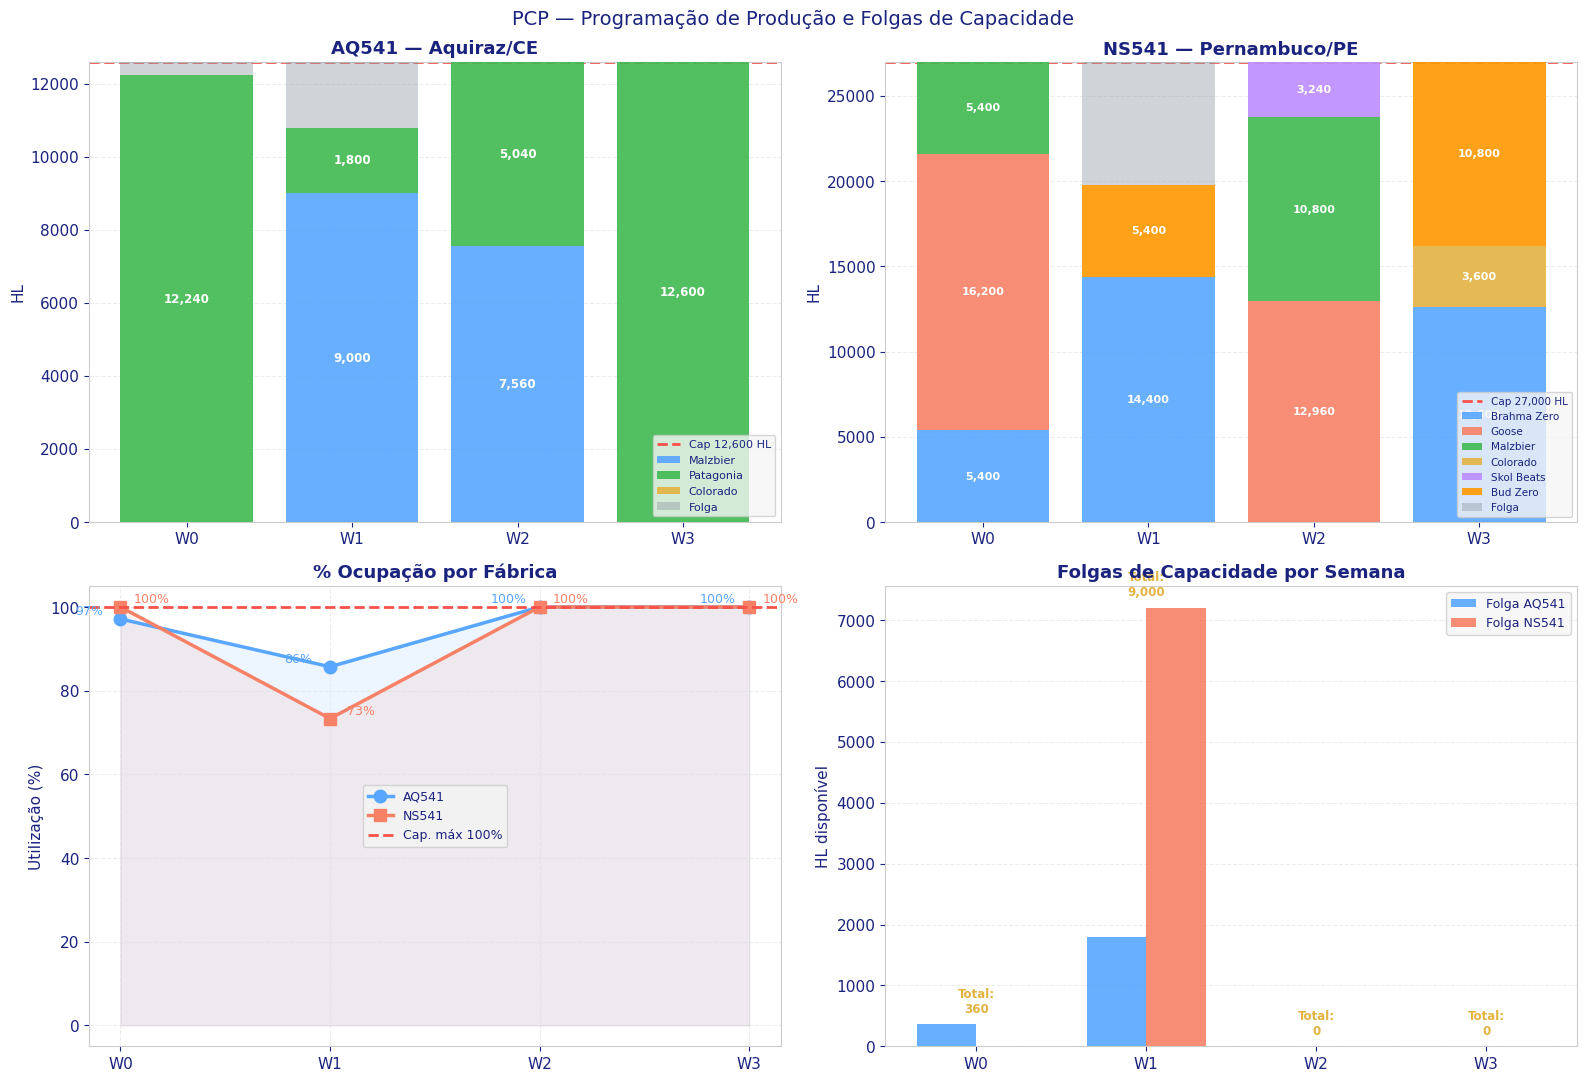

In [84]:

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('PCP — Programação de Produção e Folgas de Capacidade', fontsize=14)
axes = axes.flatten()

xp = np.arange(4)

# AQ541 — stacked
ax = axes[0]
skus_aq = list(pcp_aq.keys())
cores_aq = [ANTES, VERDE, AMARELO]
bot = np.zeros(4)
for sku, cor in zip(skus_aq, cores_aq):
    vals = np.array(pcp_aq[sku])
    ax.bar(xp, vals, bottom=bot, color=cor, alpha=0.9, label=sku.capitalize(), zorder=3)
    for i, v in enumerate(vals):
        if v > 300:
            ax.text(i, bot[i]+v/2, f'{v:,.0f}', ha='center', va='center',
                    fontsize=8.5, color='white', fontweight='bold')
    bot += vals
# Folga AQ
folga_aq = [cap_aq - tot_aq[i] for i in range(4)]
ax.bar(xp, folga_aq, bottom=bot, color=CINZA, alpha=0.4, label='Folga', zorder=3)
ax.axhline(cap_aq, color=VERMELHO, lw=2, ls='--', label=f'Cap {cap_aq:,} HL')
ax.set_xticks(xp); ax.set_xticklabels(SEMS_S); ax.set_ylabel('HL')
ax.set_title('AQ541 — Aquiraz/CE'); ax.legend(fontsize=8, loc='lower right')
ax.grid(axis='y', zorder=0)

# NS541 — stacked
ax2 = axes[1]
skus_ns = list(pcp_ns.keys())
cores_ns = [ANTES, DEPOIS, VERDE, AMARELO, ROXO, '#ff9800']
bot2 = np.zeros(4)
labels_ns = ['Brahma Zero','Goose','Malzbier','Colorado','Skol Beats','Bud Zero']
for sku, cor, lbl in zip(skus_ns, cores_ns, labels_ns):
    vals = np.array(pcp_ns[sku])
    ax2.bar(xp, vals, bottom=bot2, color=cor, alpha=0.9, label=lbl, zorder=3)
    for i, v in enumerate(vals):
        if v > 500:
            ax2.text(i, bot2[i]+v/2, f'{v:,.0f}', ha='center', va='center',
                     fontsize=8, color='white', fontweight='bold')
    bot2 += vals
folga_ns = [cap_ns - tot_ns[i] for i in range(4)]
ax2.bar(xp, folga_ns, bottom=bot2, color=CINZA, alpha=0.4, label='Folga', zorder=3)
ax2.axhline(cap_ns, color=VERMELHO, lw=2, ls='--', label=f'Cap {cap_ns:,} HL')
ax2.set_xticks(xp); ax2.set_xticklabels(SEMS_S); ax2.set_ylabel('HL')
ax2.set_title('NS541 — Pernambuco/PE'); ax2.legend(fontsize=7.5, loc='lower right')
ax2.grid(axis='y', zorder=0)

# Utilização %
ax3 = axes[2]
util_aq = [t/cap_aq*100 for t in tot_aq]
util_ns = [t/cap_ns*100 for t in tot_ns]
ax3.plot(xp, util_aq, 'o-', color=ANTES,  lw=2.5, ms=9, label='AQ541')
ax3.plot(xp, util_ns, 's-', color=DEPOIS, lw=2.5, ms=9, label='NS541')
ax3.axhline(100, color=VERMELHO, lw=2, ls='--', label='Cap. máx 100%')
ax3.fill_between(xp, 0, util_aq, alpha=0.1, color=ANTES)
ax3.fill_between(xp, 0, util_ns, alpha=0.1, color=DEPOIS)
for i,(a,n) in enumerate(zip(util_aq,util_ns)):
    ax3.text(i-0.15, a+1, f'{a:.0f}%', ha='center', fontsize=9, color=ANTES)
    ax3.text(i+0.15, n+1, f'{n:.0f}%', ha='center', fontsize=9, color=DEPOIS)
ax3.set_xticks(xp); ax3.set_xticklabels(SEMS_S); ax3.set_ylabel('Utilização (%)')
ax3.set_title('% Ocupação por Fábrica'); ax3.legend(fontsize=9); ax3.grid(zorder=0)

# Folgas disponíveis
ax4 = axes[3]
ax4.bar(xp-w/2, [cap_aq-t for t in tot_aq], w, color=ANTES,  alpha=0.9, label='Folga AQ541', zorder=3)
ax4.bar(xp+w/2, [cap_ns-t for t in tot_ns], w, color=DEPOIS, alpha=0.9, label='Folga NS541', zorder=3)
tot_folga = [(cap_aq-a)+(cap_ns-n) for a,n in zip(tot_aq,tot_ns)]
for i,f in enumerate(tot_folga):
    ax4.text(i, max((cap_aq-tot_aq[i]),(cap_ns-tot_ns[i]))+200,
             f'Total:\n{f:,.0f}', ha='center', fontsize=8.5, color=AMARELO, fontweight='bold')
ax4.set_xticks(xp); ax4.set_xticklabels(SEMS_S); ax4.set_ylabel('HL disponível')
ax4.set_title('Folgas de Capacidade por Semana'); ax4.legend(fontsize=9)
ax4.grid(axis='y', zorder=0)

plt.tight_layout(); plt.savefig('g9_pcp.png', dpi=150, bbox_inches='tight',
    facecolor='#ffffff'); plt.show()


## 10. Painel Executivo — Resumo Comparativo

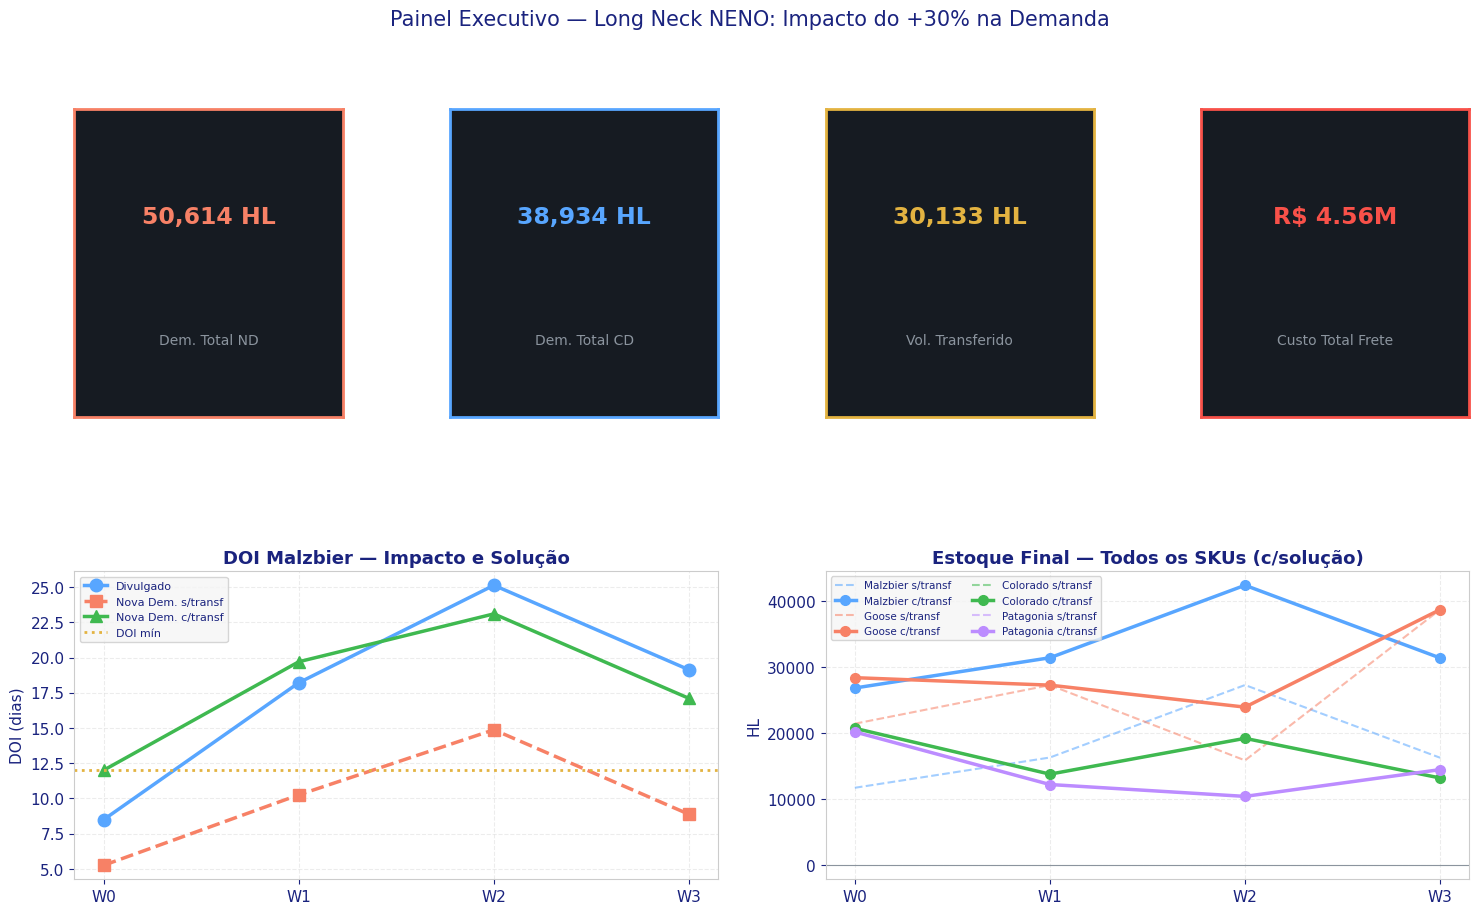


RESUMO EXECUTIVO — TRANSFERÊNCIAS SP → NENO
SKU                  HL    Custo Total              Semanas
-----------------------------------------------------------------
Malzbier         15,103   R$ 2.359.360            W0 (rodo)
Goose            15,030   R$ 2.203.483       W0 e W2 (rodo)
Colorado              —              —          sem transf.
Patagonia             —              —             sem rota
-----------------------------------------------------------------
TOTAL            30,133   R$ 4.562.843


In [85]:

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.4)
fig.suptitle('Painel Executivo — Long Neck NENO: Impacto do +30% na Demanda', fontsize=15)

xp = np.arange(4)

# KPI boxes (texto)
kpis = [
    ('Dem. Total ND', f'{sum(dem_tot_nd):,.0f} HL', DEPOIS),
    ('Dem. Total CD', f'{sum(dem_tot_cd):,.0f} HL', ANTES),
    ('Vol. Transferido', f'{sum(transf_malz["transf"])+sum(transf_goose["transf"]):,.0f} HL', AMARELO),
    ('Custo Total Frete', f'R$ {(custo_malz+custo_goose)/1e6:.2f}M', VERMELHO),
]
for i, (lbl, val, cor) in enumerate(kpis):
    ax_k = fig.add_subplot(gs[0, i])
    ax_k.set_facecolor(AX_BG)
    ax_k.text(0.5, 0.65, val, ha='center', va='center', fontsize=17,
              fontweight='bold', color=cor, transform=ax_k.transAxes)
    ax_k.text(0.5, 0.25, lbl, ha='center', va='center', fontsize=10,
              color=CINZA, transform=ax_k.transAxes)
    for spine in ax_k.spines.values():
        spine.set_edgecolor(cor); spine.set_linewidth(2)
    ax_k.set_xticks([]); ax_k.set_yticks([])

# DOI Malzbier antes/depois
ax1 = fig.add_subplot(gs[1, 0:2])
ax1.plot(xp, [r['DOI'] for r in bal_cd], 'o-',  color=ANTES,  lw=2.5, ms=9, label='Divulgado')
ax1.plot(xp, [r['DOI'] for r in bal_nd], 's--', color=DEPOIS, lw=2.5, ms=9, label='Nova Dem. s/transf')
ax1.plot(xp, transf_malz['doi_f'],        '^-',  color=VERDE,  lw=2.5, ms=9, label='Nova Dem. c/transf')
ax1.axhline(12, color=AMARELO, lw=2, ls=':', label='DOI mín')
ax1.set_xticks(xp); ax1.set_xticklabels(SEMS_S); ax1.set_ylabel('DOI (dias)')
ax1.set_title('DOI Malzbier — Impacto e Solução'); ax1.legend(fontsize=8); ax1.grid(zorder=0)

# EF Todos SKUs
ax2 = fig.add_subplot(gs[1, 2:4])
ef_all_nd = ([r['EF'] for r in bal_nd], transf_goose['ef_st'], colorado_ef, patagonia_ef)
ef_all_cf = (transf_malz['ef_f'], transf_goose['ef_f'], colorado_ef, patagonia_ef)
cores_ef  = [ANTES, DEPOIS, VERDE, ROXO]
labels_ef = ['Malzbier', 'Goose', 'Colorado', 'Patagonia']
for j, (ef_nd_s, ef_cf_s, lbl, cor) in enumerate(zip(ef_all_nd, ef_all_cf, labels_ef, cores_ef)):
    ax2.plot(xp, ef_nd_s, '--', color=cor, lw=1.5, alpha=0.55, label=f'{lbl} s/transf')
    ax2.plot(xp, ef_cf_s, '-',  color=cor, lw=2.5, ms=7, marker='o', label=f'{lbl} c/transf')
ax2.axhline(0, color=CINZA, lw=0.8)
ax2.set_xticks(xp); ax2.set_xticklabels(SEMS_S); ax2.set_ylabel('HL')
ax2.set_title('Estoque Final — Todos os SKUs (c/solução)'); ax2.legend(fontsize=7.5, ncol=2)
ax2.grid(zorder=0)

plt.savefig('g10_executivo.png', dpi=150, bbox_inches='tight', facecolor='#ffffff'); plt.show()

# Tabela resumo final
print("\n" + "="*65)
print("RESUMO EXECUTIVO — TRANSFERÊNCIAS SP → NENO")
print("="*65)
print(f"{'SKU':<14} {'HL':>8} {'Custo Total':>14} {'Semanas':>20}")
print("-"*65)
print(f"{'Malzbier':<14} {sum(transf_malz['transf']):>8,.0f} {'R$ 2.359.360':>14} {'W0 (rodo)':>20}")
print(f"{'Goose':<14} {sum(transf_goose['transf']):>8,.0f} {'R$ 2.203.483':>14} {'W0 e W2 (rodo)':>20}")
print(f"{'Colorado':<14} {'—':>8} {'—':>14} {'sem transf.':>20}")
print(f"{'Patagonia':<14} {'—':>8} {'—':>14} {'sem rota':>20}")
print("-"*65)
tot_hl_all = sum(transf_malz['transf'])+sum(transf_goose['transf'])
print(f"{'TOTAL':<14} {tot_hl_all:>8,.0f} {'R$ 4.562.843':>14}")
print("="*65)
